# **TrustJob KZ - Fake Job Posting Detection System**
## Machine Learning Training Notebook 
### Multilingual · Kazakhstan-Ready · Dual-Model Architecture

---

**Project:** TrustJob KZ  
**Task:** Binary Classification - Detect Fraudulent Job Postings  
**Training Dataset:** [EMSCAD - Kaggle](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction)  
**Deployment Target:** Kazakhstan job market (Russian/Kazakh language support)

---

### Architecture Overview

| Model | Features | Best for |
|---|---|---|
| **Model A - Text-Only** | TF-IDF on combined text | Robust deployment; any input |
| **Model B - Hybrid** | Text + engineered numeric features | Higher accuracy with metadata |

**Core design principles:**
- Single canonical schema normalises any job dataset via `standardize_job_dataframe()`
- Optional Russian => English translation at inference (not during training)
- Bilingual suspicious keyword detector (EN + RU + KZ)
- Final risk = 0.8 × ML probability + 0.2 × rule score


---
## **1. Install & Import Libraries**

In [3]:
import os, re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, log_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from scipy.sparse import hstack, csr_matrix, vstack as sp_vstack
import joblib
from collections import Counter

try:
    from xgboost import XGBClassifier; XGBOOST_OK = True; print('XGBoost')
except ImportError:
    XGBOOST_OK = False; print('XGBoost not available - skipping')

try:
    from lightgbm import LGBMClassifier; LGBM_OK = True; print('LightGBM')
except ImportError:
    LGBM_OK = False; print('LightGBM not available - skipping')

try:
    from imblearn.over_sampling import SMOTE; SMOTE_OK = True; print('SMOTE')
except ImportError:
    SMOTE_OK = False; print('imbalanced-learn not available')

try:
    import shap; SHAP_OK = True; print('SHAP')
except ImportError:
    SHAP_OK = False; print('SHAP not available')

try:
    from deep_translator import GoogleTranslator; TRANSLATE_OK = True; print('deep-translator')
except ImportError:
    TRANSLATE_OK = False; print('deep-translator not installed - translation disabled')

os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42
print('\nCore libraries loaded.')


XGBoost
LightGBM
SMOTE
SHAP
deep-translator

Core libraries loaded.


---
## **2. Schema Standardisation Layer**

### Why is this needed?

The Kaggle EMSCAD dataset and the Kazakhstan job dataset have **different column names and structures**. We define one canonical schema and map every dataset into it automatically.

**Canonical schema:**

| Column | Type | Default if missing |
|---|---|---|
| title, company_profile, description, requirements, benefits | text | `""` |
| salary_range, location, employment_type, industry | text | `""` |
| telecommuting, has_company_logo, has_questions | binary int | `0` |
| fraudulent | int | required for training only |


In [4]:
# Canonical schema definition 
CANONICAL_TEXT_COLS   = ['title','company_profile','description',
                         'requirements','benefits','salary_range',
                         'location','employment_type','industry']
CANONICAL_BINARY_COLS = ['telecommuting','has_company_logo','has_questions']
CANONICAL_TARGET      = 'fraudulent'

# Kazakhstan column name mapping (edit as needed)
# key = column name in KZ dataset  =>  value = canonical name
KZ_COLUMN_MAP = {
    'job_title'        : 'title',
    'title_ru'         : 'title',
    'name'             : 'title',
    'vacancy'          : 'title',
    'job_description'  : 'description',
    'description_ru'   : 'description',
    'text'             : 'description',
    'body'             : 'description',
    'company'          : 'company_profile',
    'company_name'     : 'company_profile',
    'employer'         : 'company_profile',
    'organization'     : 'company_profile',
    'city'             : 'location',
    'region'           : 'location',
    'address'          : 'location',
    'salary'           : 'salary_range',
    'wage'             : 'salary_range',
    'зарплата'         : 'salary_range',
    'требования'       : 'requirements',
    'условия'          : 'benefits',
    'отрасль'          : 'industry',
    'сфера'            : 'industry',
    'тип_занятости'    : 'employment_type',
    'is_fake'          : 'fraudulent',
    'label'            : 'fraudulent',
    'fraud'            : 'fraudulent',
    'fake'             : 'fraudulent',
}


def standardize_job_dataframe(df: pd.DataFrame, source: str = 'kaggle') -> pd.DataFrame:
    """
    Convert any job dataset into the canonical schema.

    Parameters
    ----------
    df     : raw DataFrame
    source : 'kaggle' | 'kazakhstan' | 'user_input'

    Returns
    -------
    DataFrame with canonical columns; missing ones filled with safe defaults.
    """
    df = df.copy()

    if source == 'kazakhstan':
        rename_map = {k: v for k, v in KZ_COLUMN_MAP.items() if k in df.columns}
        if rename_map:
            df = df.rename(columns=rename_map)
            print(f'  [standardize] Renamed: {rename_map}')

    df.columns = [c.lower().strip() for c in df.columns]

    for col in CANONICAL_TEXT_COLS:
        if col not in df.columns:
            df[col] = ''

    for col in CANONICAL_BINARY_COLS:
        if col not in df.columns:
            df[col] = 0

    for col in CANONICAL_TEXT_COLS:
        df[col] = df[col].fillna('').astype(str)
    for col in CANONICAL_BINARY_COLS:
        df[col] = df[col].fillna(0).astype(int)

    all_cols = CANONICAL_TEXT_COLS + CANONICAL_BINARY_COLS
    if CANONICAL_TARGET in df.columns:
        df[CANONICAL_TARGET] = df[CANONICAL_TARGET].astype(int)
        all_cols = all_cols + [CANONICAL_TARGET]

    return df[all_cols]


print('standardize_job_dataframe() defined.')


standardize_job_dataframe() defined.


---
## **3. Load & Standardise the Kaggle Dataset**

> Download `fake_job_postings.csv` from [Kaggle](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction) and place it in the same folder as this notebook.


In [19]:
DATA_PATH = '/Users/aruzhantleukul/Desktop/machine learning/TrustJob/fake_job_postings.csv'
df = pd.read_csv(
    DATA_PATH,
    encoding="utf-8",
    engine="python",
    sep=None,
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


---
## **4. Academic Motivation**

### **4.1 Why train on Kaggle (EMSCAD)?**

The EMSCAD corpus contains ~18,000 expert-labelled job postings - the largest available benchmark for this task. It provides rich text fields, metadata signals, and a realistic imbalance ratio (~5% fraud) mirroring real-world conditions.

### **4.2 Why use Kazakhstan data separately?**

Kazakhstan job postings appear in Russian, Kazakh, or mixed language and use locally specific scam patterns. The KZ dataset is used for:
- Local rule-score calibration
- Manual/qualitative testing of the deployed model
- Future fine-tuning once labelled Kazakh data is collected

### **4.3 Why is accuracy misleading here?**

With ~95% real vs ~5% fake, a model that labels *everything* as Real achieves **95% accuracy** but detects **zero fraud**. We therefore optimise for:

| Metric | Meaning |
|---|---|
| **Recall (Fake)** | What fraction of real fakes do we catch? |
| **Precision (Fake)** | Of jobs we flag, how many are truly fake? |
| **F1-score (Fake)** | Harmonic mean — single balanced fraud metric |
| **ROC-AUC** | Overall discriminative power across all thresholds |

### **4.4 Why a text-only model for deployment?**

The hybrid model relies on `has_company_logo`, `has_questions`, and `telecommuting` — Kaggle-specific metadata absent on the TrustJob KZ website. The text-only model:
- Works with **any input** (minimum: title + description)
- Is language-agnostic after translation
- Generalises across platforms and datasets


---
## **5. Initial Data Understanding**

In [20]:
print('Shape:', df.shape)

counts = df['fraudulent'].value_counts()
pcts   = df['fraudulent'].value_counts(normalize=True) * 100
dist   = pd.DataFrame({'Count': counts, 'Pct (%)': pcts.round(2)})
dist.index = ['Real (0)', 'Fake (1)']
print('\nTarget Distribution:')
print(dist)
print(f'\nImbalance ratio → {counts[0]:,} Real : {counts[1]:,} Fake  ({counts[0]/counts[1]:.1f}:1)')


Shape: (17880, 18)

Target Distribution:
          Count  Pct (%)
Real (0)  17014    95.16
Fake (1)    866     4.84

Imbalance ratio → 17,014 Real : 866 Fake  (19.6:1)


### **5.2 Data Preprocessing: Handling Missing Values & Duplicates**

To ensure the reliability of our analysis, we perform a quality check on the dataset:
1. **Missing Data:** We quantify the gaps in our data. Handling missing values is crucial for NLP tasks as algorithms like TF-IDF cannot process null inputs.
2. **Duplicate Removal:** We eliminate duplicates (matching Title and Description) to ensure that repeated job postings do not skew the frequency of "suspicious" words.

In [21]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Missing (%)': missing_pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Missing (%)', ascending=False)
print('Columns with missing values:')
print(miss_df if len(miss_df) else '  None (standardizer filled all defaults)')

n_dupes = df.duplicated(subset=['title','description']).sum()
print(f'\nApproximate duplicates (title+desc): {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates(subset=['title','description']).reset_index(drop=True)
    print(f'  => Removed. New shape: {df.shape}')


Columns with missing values:
                     Missing  Missing (%)
salary_range           15012        83.96
department             11547        64.58
required_education      8105        45.33
benefits                7212        40.34
required_experience     7050        39.43
function                6455        36.10
industry                4903        27.42
employment_type         3471        19.41
company_profile         3308        18.50
requirements            2696        15.08
location                 346         1.94
description                1         0.01

Approximate duplicates (title+desc): 2093
  => Removed. New shape: (15787, 18)


---
## **6. Exploratory Data Analysis (EDA)**

### **6.1 Class Distribution: Analyzing Label Imbalance**

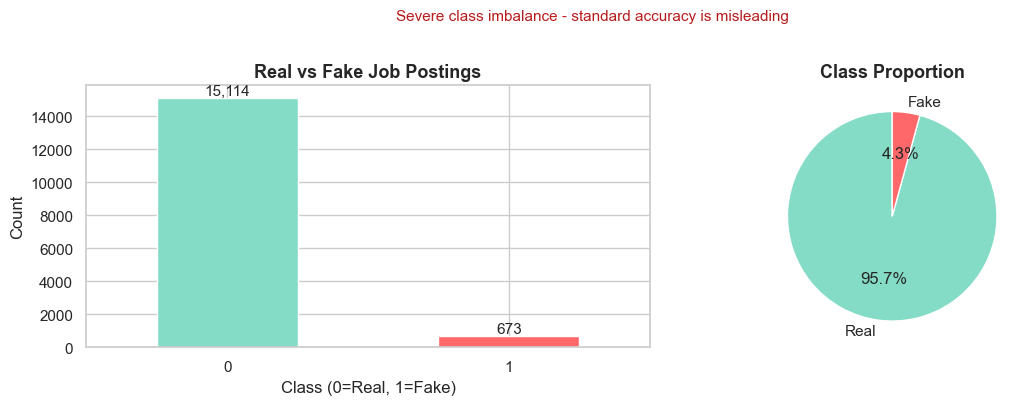

In [24]:
COLORS = ['#84dcc6','#ff686b']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['fraudulent'].value_counts().plot(kind='bar', ax=axes[0],
    color=COLORS, edgecolor='white', rot=0)
axes[0].set_title('Real vs Fake Job Postings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class (0=Real, 1=Fake)'); axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=11)

sizes = df['fraudulent'].value_counts().values
axes[1].pie(sizes, labels=['Real','Fake'], colors=COLORS,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Severe class imbalance - standard accuracy is misleading',
             fontsize=11, color='#B71C1C', y=1.01)
plt.tight_layout()
plt.savefig('models/eda_01_class_dist.png', dpi=120, bbox_inches='tight')
plt.show()


### **6.2 Missing Data Correlation: The "Lazy Fraudster" Hypothesis**
We investigate whether the absence of information in certain fields serves as a signal for fraudulent activity.

* **Metric:** We calculate the percentage of missing values per column, grouped by the `fraudulent` label.
* **Key Indicators:** Significant discrepancies in fields like `company_profile`, `requirements`, or `benefits` often highlight a lack of legitimacy in the posting.
* **Methodology:** Values are considered missing if they are explicitly `NaN` or contain empty strings/whitespace.

In [29]:
missing_cols = ["company_profile", "requirements", "benefits", "salary_range", "location"]

eda_df = df.copy()

for col in missing_cols:
    eda_df[col + "_missing"] = (
        eda_df[col].isna() | 
        (eda_df[col].astype(str).str.strip() == "")
    )

missing_by_class = eda_df.groupby("fraudulent")[[col + "_missing" for col in missing_cols]].mean() * 100

missing_by_class.index = missing_by_class.index.map({0: "Real", 1: "Fake"})
missing_by_class = missing_by_class.T
missing_by_class.index = [col.replace("_missing", "") for col in missing_by_class.index]

missing_by_class


fraudulent,Real,Fake
company_profile,17.162895,68.499257
requirements,14.337700,18.870728
benefits,41.656742,46.210996
salary_range,83.624454,71.768202
location,2.110626,2.228826


### **6.3 Comparative Analysis of Missing Fields**
This visualization confirms that **incomplete job postings are a strong indicator of fraud.** 
* **Observation:** The significant gap between the red (Fake) and teal (Real) bars suggests that fraudulent postings consistently lack key details, particularly in the `company_profile` and `salary_range` fields.
* **Feature Importance:** These "missingness" flags will likely be among the most influential features when training the classification model.

<Figure size 1200x600 with 0 Axes>

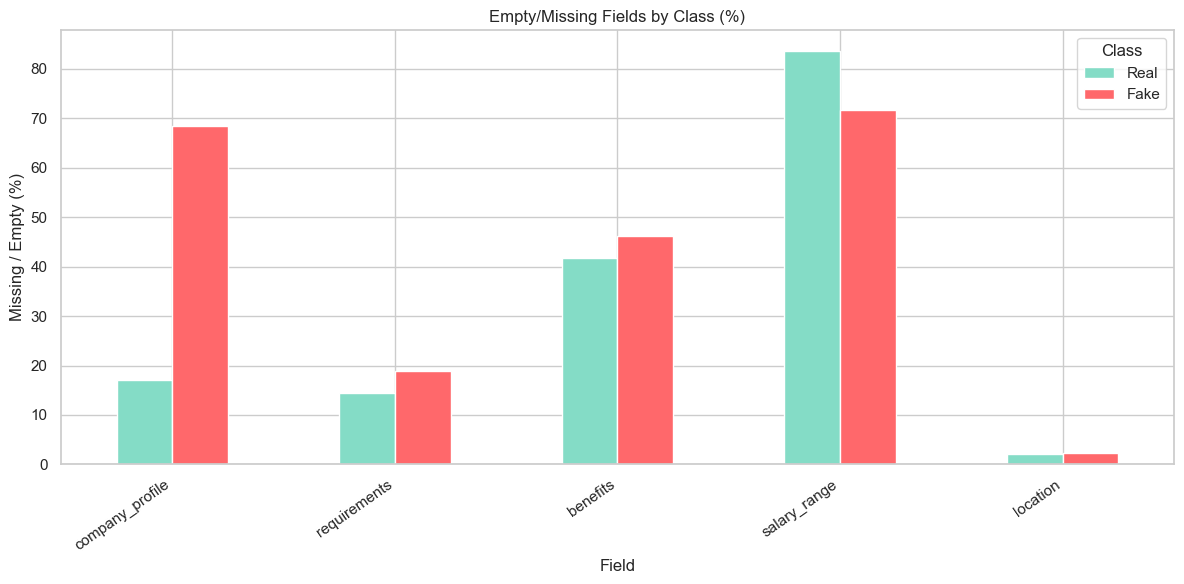

In [31]:
plt.figure(figsize=(12, 6))
missing_by_class.plot(
    kind="bar",
    figsize=(12, 6),
    color=COLORS
)

plt.title("Empty/Missing Fields by Class (%)")
plt.ylabel("Missing / Empty (%)")
plt.xlabel("Field")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### **6.4 Text Length Distribution: Real vs. Fake Descriptions**
We analyze the character count of job descriptions to determine if the length of the text serves as a distinguishing feature.

* **Distribution Shape:** Most real job descriptions follow a normal-like distribution with a peak around 1,000 characters.
* **The "Short Fake" Trend:** Fraudulent postings often have significantly shorter descriptions (lower median length), as scammers frequently provide minimal details to lure candidates quickly.
* **Outliers:** Very long descriptions are typically found in legitimate corporate postings that include extensive "About Us" and "EEO Statement" sections.

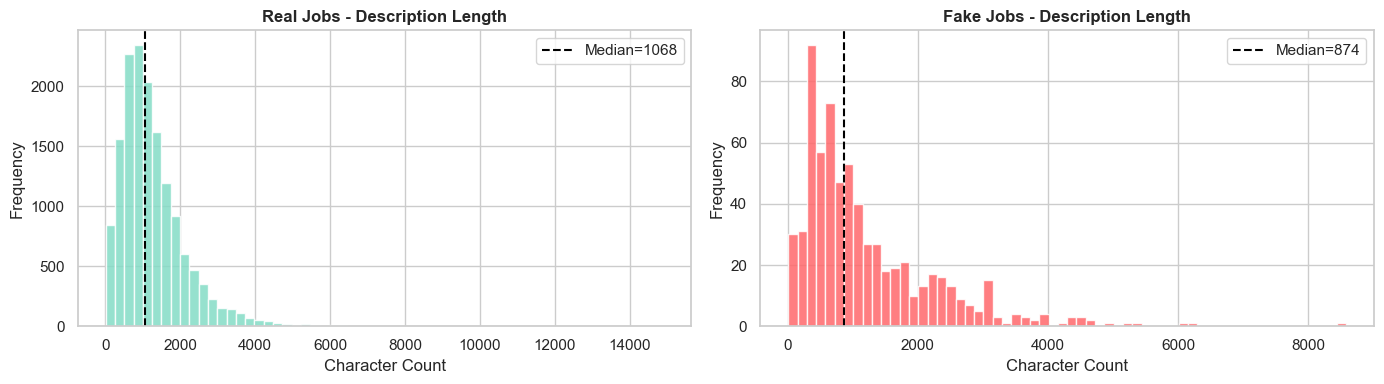

In [33]:
df['_desc_len'] = df['description'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for idx, label in enumerate([0, 1]):
    sub = df[df['fraudulent']==label]['_desc_len']
    axes[idx].hist(sub, bins=60, color=COLORS[label], edgecolor='white', alpha=0.85)
    lname = 'Real' if label == 0 else 'Fake'
    axes[idx].set_title(f'{lname} Jobs - Description Length', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Character Count'); axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(sub.median(), color='black', linestyle='--',
                      label=f'Median={sub.median():.0f}')
    axes[idx].legend()
plt.tight_layout()
plt.savefig('models/eda_03_text_length.png', dpi=120, bbox_inches='tight')
plt.show()


### **6.5 Binary Feature Analysis: Risk Factors**
We analyze the relationship between binary flags (`telecommuting`, `has_company_logo`, `has_questions`) and the likelihood of a posting being fraudulent.

* **Fraud Rate (%)**: The bars represent the percentage of postings within that specific category that are fraudulent.
* **Key Findings:** 
    * Postings **without a company logo** tend to have a significantly higher risk profile.
    * The **absence of screening questions** is a common trait among fraudulent entries, as they aim to minimize barriers for potential victims.
    * **Telecommuting** (Remote work) is a frequent bait used in fraudulent schemes.

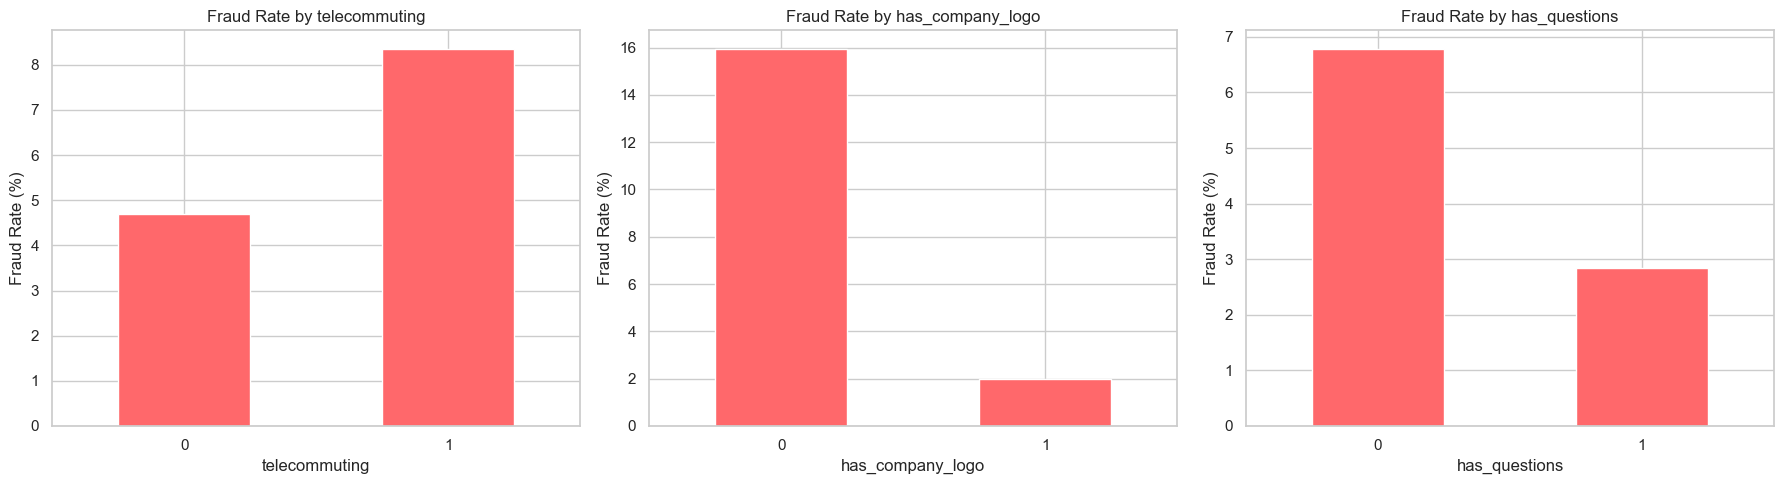

In [35]:
binary_cols = ["telecommuting", "has_company_logo", "has_questions"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, binary_cols):
    fraud_rate = df.groupby(col)["fraudulent"].mean() * 100
    
    fraud_rate.plot(
        kind="bar",
        ax=ax,
        color=COLORS[1]
    )
    
    ax.set_title(f"Fraud Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_xticklabels(["0", "1"], rotation=0)

plt.tight_layout()
plt.show()


### **6.6 Quantitative Analysis: Binary Feature Statistics**
To support our visualizations, we generate detailed statistics for each binary indicator.

In [92]:
for col in binary_cols:
    print(f"\nAnalysis for: {col}")
    stats = (
        df.groupby(col)["fraudulent"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Jobs",
            "sum": "Fake_Jobs",
            "mean": "Fraud_Rate"
        })
    )
    
    display(stats.style.background_gradient(subset=['Fraud_Rate'], cmap='Reds')
                       .format({'Fraud_Rate': '{:.2%}'}))


Analysis for: telecommuting


,Total_Jobs,Fake_Jobs,Fraud_Rate
telecommuting,,,
0,15120,620,4.10%
1,667,53,7.95%



Analysis for: has_company_logo


,Total_Jobs,Fake_Jobs,Fraud_Rate
has_company_logo,,,
0,3205,455,14.20%
1,12582,218,1.73%



Analysis for: has_questions


,Total_Jobs,Fake_Jobs,Fraud_Rate
has_questions,,,
0,8081,468,5.79%
1,7706,205,2.66%


### **6.7 Contrastive TF-IDF Analysis: Identifying Fraud Markers**
While standard word counts show what is common, this **Contrastive TF-IDF** analysis reveals what is *unique* to fraudulent postings.

* **Methodology:**
    1. **Vectorization:** We convert job descriptions into TF-IDF scores, capturing both single words and bigrams (two-word phrases).
    2. **Noise Reduction:** We filter out standard English stop words and common corporate jargon (e.g., "team", "work", "company") that appear in both classes.
    3. **Difference Scoring:** We subtract the average importance scores of Real jobs from Fake jobs. 
* **Key Findings:** * Positive scores indicate words that are significantly more characteristic of **Fake** postings.
    * Phrases like **"data entry"**, **"earn"**, and **"oil and gas"** emerge as high-risk indicators, providing the model with strong linguistic cues for detection.

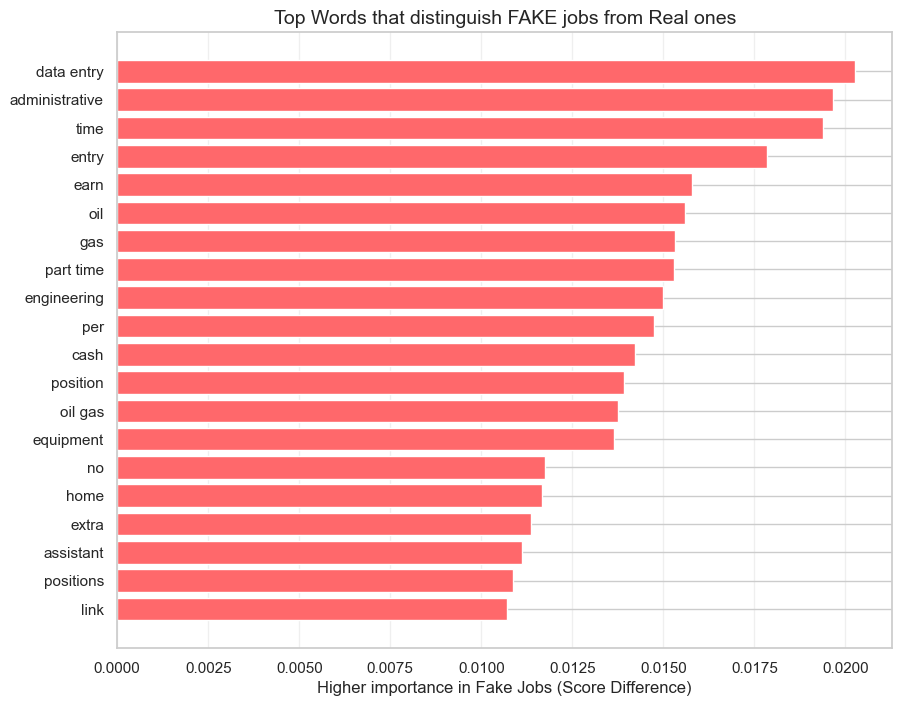

In [43]:
EN_STOP = set("""
a an the and or but if then else when while for to of in on at by with from as is are was were
be been being have has had do does did can could should would may might must will just this that
these those it its into about your you we our they their he she his her them than
""".split())

stop_words_extra = list(EN_STOP) + ['amp', 'work', 'experience', 'team', 'company', 'business']

tfidf = TfidfVectorizer(stop_words=stop_words_extra, max_features=2000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['description'].fillna(""))

real_indices = df[df['fraudulent'] == 0].index
fake_indices = df[df['fraudulent'] == 1].index

real_scores = np.asarray(tfidf_matrix[real_indices].mean(axis=0)).ravel()
fake_scores = np.asarray(tfidf_matrix[fake_indices].mean(axis=0)).ravel()

words = tfidf.get_feature_names_out()
diff_df = pd.DataFrame({'word': words, 'score': fake_scores - real_scores})
top_distinctive_fake = diff_df.sort_values(by='score', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_distinctive_fake['word'][::-1], top_distinctive_fake['score'][::-1], color='#ff686b')
plt.title('Top Words that distinguish FAKE jobs from Real ones', fontsize=14)
plt.xlabel('Higher importance in Fake Jobs (Score Difference)')
plt.grid(axis='x', alpha=0.3)
plt.show()

### **6.8 Relative Risk by Employment Type (Normalized)**
To better understand which employment categories are most susceptible to fraud, we analyze the internal distribution of each type.

* **Methodology:** We use a **Stacked Bar Chart** normalized to 100%. This allows us to compare the *proportion* of fake jobs across categories, regardless of how many total postings exist in each group.
* **Key Findings:** 
    * **Part-time** positions show a noticeably higher fraud rate (~9.2%) compared to **Full-time** roles. 
    * **Temporary** and **Full-time** roles appear to be the "safest," with the lowest percentage of fraudulent activity.
* **Insight:** Scammers tend to target the "Part-time" and "Other" categories, likely because these roles often attract applicants looking for quick or flexible work with fewer barrier-to-entry requirements.

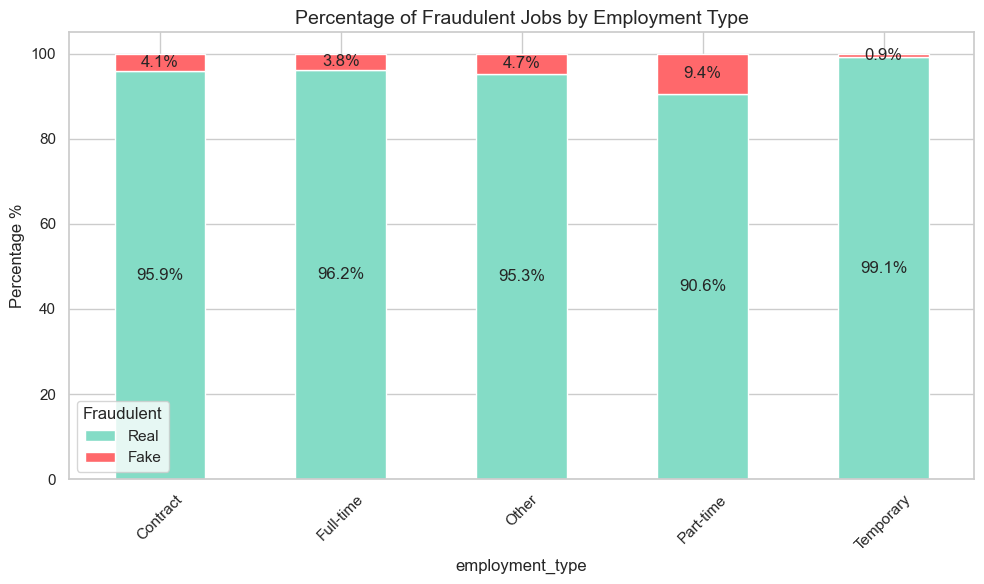

In [47]:
ct = pd.crosstab(df['employment_type'], df['fraudulent'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#84dcc6', '#ff686b'])

plt.title('Percentage of Fraudulent Jobs by Employment Type', fontsize=14)
plt.ylabel('Percentage %')
plt.xticks(rotation=45)
plt.legend(title='Fraudulent', labels=['Real', 'Fake'])

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: 
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center')

plt.tight_layout()
plt.show()

---
## **7. Language Handling - Russian / Kazakh Translation**

### Why translate?

The TF-IDF vocabulary is built from **English training data**. Russian/Kazakh text contains out-of-vocabulary tokens and would produce near-zero feature vectors, causing the model to default to "Real". Translation bridges this gap at inference time.

**Design rules:**
- Translate **only text fields**: title, description, requirements, company_profile, benefits
- Never translate: salary, location, company name, URLs, numbers
- If no translation API is connected, the function returns the original text unchanged — the rule-based score still works for RU/KZ


In [49]:
TRANSLATE_FIELDS    = ['title','description','requirements','company_profile','benefits']
NO_TRANSLATE_FIELDS = ['salary_range','location','employment_type','industry']


def translate_job_text_to_english(text: str, enabled: bool = True) -> str:
    if not enabled or not isinstance(text, str) or len(text.strip()) == 0:
        return text

    if TRANSLATE_OK:
        try:
            result = GoogleTranslator(source='auto', target='en').translate(text)
            return result if result else text
        except Exception as e:
            print(f'  [translate] Warning: {e}')
            return text

    return text   


def translate_job_dict(job: dict, enabled: bool = True) -> dict:
    if not enabled:
        return job
    return {
        k: (translate_job_text_to_english(v, enabled=True)
            if k in TRANSLATE_FIELDS and isinstance(v, str) else v)
        for k, v in job.items()
    }


print('translate_job_text_to_english() defined.')
print(f'   Translation available: {TRANSLATE_OK}')
print(f'   Fields translated    : {TRANSLATE_FIELDS}')


translate_job_text_to_english() defined.
   Translation available: True
   Fields translated    : ['title', 'description', 'requirements', 'company_profile', 'benefits']


---
## **8. Local Kazakhstan Rule-Based Detector**

A bilingual keyword detector provides a **fast, transparent, language-aware** fraud signal that complements the ML model — especially for Russian/Kazakh text before (or without) translation.


In [51]:
# Bilingual suspicious keyword lists
SUSPICIOUS_KW_EN = [
    'no experience needed','no experience required','easy money',
    'earn money fast','make money online','work from home',
    'be your own boss','unlimited earning','weekly pay','daily pay',
    'financial freedom','passive income','get rich quick',
    'guaranteed income','risk free','wire transfer','western union',
    'money order','pyramid','multi-level','mlm','urgent hiring',
    'apply immediately','limited slots','whatsapp','telegram',
    'cash daily','no investment required','payment for training','upfront fee',
]

SUSPICIOUS_KW_RU = [
    'без опыта','не требуется опыт','опыт не нужен',
    'ежедневная оплата','оплата каждый день','еженедельная оплата',
    'предоплата','оплата за обучение','взнос за',
    'быстрый доход','высокий доход','лёгкий заработок',
    'легкий заработок','быстрый заработок','большой доход',
    'пишите в whatsapp','пишите в вотсап','написать в телеграм',
    'работа на дому','удалённая работа','удаленная работа',
    'без вложений','не нужно вкладывать','сетевой маркетинг',
    'многоуровневый маркетинг','срочный набор',
    'набор сотрудников срочно','гарантированный доход',
    'обучение за счёт','обучение бесплатно',
]

SUSPICIOUS_KW_KZ = [
    'тәжірибе қажет емес','жұмыс үйде','тез табыс',
    'whatsapp жазыңыз','telegram жазыңыз','күнделікті төлем',
]

ALL_SUSPICIOUS_KW = SUSPICIOUS_KW_EN + SUSPICIOUS_KW_RU + SUSPICIOUS_KW_KZ


def calculate_local_rule_score(text: str) -> dict:
    if not isinstance(text, str):
        return {'suspicious_keyword_count': 0,
                'local_rule_score': 0.0,
                'detected_phrases': []}

    text_lower = text.lower()
    detected   = list(set(kw for kw in ALL_SUSPICIOUS_KW if kw in text_lower))
    count      = len(detected)
    score      = round(min(count / 5.0, 1.0), 4)   # 5 phrases → max score

    return {'suspicious_keyword_count': count,
            'local_rule_score'        : score,
            'detected_phrases'        : detected}


demos = [
    ('RU scam', 'Срочный набор! Работа на дому, без опыта. Пишите в WhatsApp. Ежедневная оплата!'),
    ('EN scam', 'Easy money guaranteed! No experience needed. Work from home. Get rich quick.'),
    ('Real',    'Senior Python Engineer, 5+ years, competitive salary and full benefits package.'),
]
for label, text in demos:
    r = calculate_local_rule_score(text)
    print(f'[{label}]  score={r["local_rule_score"]}  '
          f'count={r["suspicious_keyword_count"]}  phrases={r["detected_phrases"]}')


[RU scam]  score=1.0  count=6  phrases=['пишите в whatsapp', 'ежедневная оплата', 'whatsapp', 'работа на дому', 'срочный набор', 'без опыта']
[EN scam]  score=0.8  count=4  phrases=['get rich quick', 'no experience needed', 'work from home', 'easy money']
[Real]  score=0.0  count=0  phrases=[]


---
## **9. Text Preprocessing & Feature Engineering**

### **9.1 Text Standardization and Feature Fusion**
* **Text Consolidation:** We merge `title`, `company_profile`, `description`, `requirements`, and `benefits` into a single `combined_text` feature. This allows the model to capture thematic relationships across different sections of the job posting.
* **Cleaning Pipeline:**
    1. **Normalization:** Converting all text to lowercase.
    2. **HTML Removal:** Stripping out tags (like `<p>` or `<div>`) that often appear in web-scraped data.
    3. **URL Stripping:** Removing links and web addresses to eliminate noise.
    4. **Sanitization:** Removing special characters and punctuation, leaving only alphanumeric characters.
    5. **Whitespace Normalization:** Ensuring consistent spacing for cleaner tokenization.
* **Outcome:** A standardized, "clean" string ready for TF-IDF or Word Embedding transformations.

In [110]:
def clean_text(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>',          ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\u0400-\u04FF\s]', ' ', text)
    return re.sub(r'\s+',               ' ', text).strip()


TEXT_FIELDS = ['title','company_profile','description','requirements','benefits']

df['combined_text'] = df.apply(
    lambda row: clean_text(' '.join(str(row.get(c,'')) for c in TEXT_FIELDS)),
    axis=1
)

print('Sample combined text (120 chars):')
print(df['combined_text'].iloc[0][:120])
print(f'Avg length: {df["combined_text"].str.len().mean():.0f} chars')


Sample combined text (120 chars):
marketing intern we re food52 and we ve created a groundbreaking and award winning cooking site we support connect and c
Avg length: 2703 chars


In [111]:
def detect_language(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 'en'
    cyrillic = sum(1 for c in text if '\u0400' <= c <= '\u04FF')
    ratio = cyrillic / max(len(text.replace(' ', '')), 1)
    return 'ru' if ratio > 0.20 else 'en'

print(detect_language("Работа на дому, без опыта"))  
print(detect_language("Senior Python Developer"))      

ru
en


### **9.2 Numeric Feature Engineering and Domain Rules**
* **Text Density Metrics:** We calculate `text_length` and `word_count` to capture the descriptive depth of the posting.
* **Missing Value Indicators:** We binarize the absence of information in key fields (Salary, Company Profile, etc.) and create a `total_missing_fields` score. This quantifies the "completeness" of the job ad.
* **Domain-Specific Heuristics:** 
    * **`suspicious_keyword_count`**: Counts high-risk terms (e.g., "money", "earn", "payroll").
    * **`local_rule_score`**: A custom weighted score based on predefined domain rules (heuristics) that penalize common scam patterns.
* **Purpose:** These features provide the model with "shortcuts" to identify fraud, supplementing the high-dimensional TF-IDF data with low-dimensional, high-impact signals.

In [55]:
df['text_length']             = df['combined_text'].str.len()
df['word_count']              = df['combined_text'].str.split().str.len()
df['missing_salary']          = (df['salary_range']   =='').astype(int)
df['missing_company_profile'] = (df['company_profile']=='').astype(int)
df['missing_requirements']    = (df['requirements']   =='').astype(int)
df['missing_benefits']        = (df['benefits']       =='').astype(int)
df['missing_location']        = (df['location']       =='').astype(int)
df['total_missing_fields']    = (df[['missing_salary','missing_company_profile',
                                     'missing_requirements','missing_benefits']].sum(axis=1))

rule_results                  = df['combined_text'].apply(calculate_local_rule_score)
df['suspicious_keyword_count']= rule_results.apply(lambda x: x['suspicious_keyword_count'])
df['local_rule_score']        = rule_results.apply(lambda x: x['local_rule_score'])

print('Feature summary:')
df[['text_length','word_count','missing_salary','suspicious_keyword_count',
          'local_rule_score','total_missing_fields']].describe().round(2)

Feature summary:


,text_length,word_count,missing_salary,suspicious_keyword_count,local_rule_score,total_missing_fields
count,15787.00,15787.00,15787.0,15787.00,15787.00,15787.0
mean,2702.23,409.49,0.0,0.04,0.01,0.0
std,1390.11,213.60,0.0,0.20,0.04,0.0
min,30.00,6.00,0.0,0.00,0.00,0.0
25%,1689.50,259.00,0.0,0.00,0.00,0.0
50%,2549.00,382.00,0.0,0.00,0.00,0.0
75%,3455.00,524.00,0.0,0.00,0.00,0.0
max,14611.00,2203.00,0.0,3.00,0.60,0.0


### **9.3 Feature Set Architecture: Model A vs. Model B**
To evaluate the effectiveness of our feature engineering, we define two distinct feature sets for comparative modeling:

* **Model A (Text-Only / Baseline):** 
    * **Features:** Utilizes only the `combined_text` via TF-IDF vectorization.
    * **Rationale:** This serves as a "pure" NLP baseline. It tests the model's ability to detect fraud based solely on linguistic patterns and vocabulary.
* **Model B (Hybrid / Enhanced):** 
    * **Features:** Combines the TF-IDF text matrix with the 13 engineered numeric and binary features (Length, Missing Fields, Rule Scores, etc.).
    * **Rationale:** This tests the hypothesis that metadata and structural signals (like the absence of a logo or specific rule violations) significantly improve the detection of sophisticated scams.
* **Dynamic Loading:** The script automatically validates metadata availability (e.g., `has_company_logo`) before inclusion to ensure pipeline stability.

In [56]:
# Define feature sets for Model A and Model B

# Model A: text only - no numeric features (deployed on any dataset)
# Model B: text + engineered features

HYBRID_FEATURES = [
    'text_length','word_count',
    'missing_salary','missing_company_profile','missing_requirements',
    'missing_benefits','missing_location','total_missing_fields',
    'suspicious_keyword_count','local_rule_score',
]
# Add Kaggle-specific metadata only if the column exists and has non-zero values
for _col in ['has_company_logo','has_questions','telecommuting']:
    if _col in df.columns and df[_col].sum() > 0:
        HYBRID_FEATURES.append(_col)

print('Text-Only features : [combined_text via TF-IDF]')
print(f'Hybrid features    : {HYBRID_FEATURES}')


Text-Only features : [combined_text via TF-IDF]
Hybrid features    : ['text_length', 'word_count', 'missing_salary', 'missing_company_profile', 'missing_requirements', 'missing_benefits', 'missing_location', 'total_missing_fields', 'suspicious_keyword_count', 'local_rule_score', 'has_company_logo', 'has_questions', 'telecommuting']


---
## **10. Train / Validation / Test Split**

Stratified splits preserve the ~5% fraud class in every subset.

| Split | Size | Purpose |
|---|---|---|
| Train | 70% | Fit all models |
| Validation | 15% | Threshold tuning, model selection |
| Test | 15% | Final evaluation - **touched once only** |

> The test set is **sealed** until Section 15. Evaluating on the test set multiple times would constitute data leakage via human-driven model selection.

In [57]:
TARGET = 'fraudulent'
X_text = df['combined_text']
X_num  = df[HYBRID_FEATURES]
y      = df[TARGET]

X_text_tv, X_text_test, X_num_tv, X_num_test, y_tv, y_test = train_test_split(
    X_text, X_num, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

val_ratio = 0.15 / 0.85
X_text_train, X_text_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_text_tv, X_num_tv, y_tv,
    test_size=val_ratio, stratify=y_tv, random_state=RANDOM_STATE)

for name, ys in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    print(f'{name:6} | {len(ys):5,} rows | fraud rate = {ys.mean():.3%}')


Train  | 11,050 rows | fraud rate = 4.262%
Val    | 2,368 rows | fraud rate = 4.265%
Test   | 2,369 rows | fraud rate = 4.263%


---
## **11. TF-IDF Vectorisation**

Key settings:
- `ngram_range=(1,2)` - unigrams + bigrams capture multi-word scam phrases like *"no experience needed"*
- `sublinear_tf=True` - log-normalises TF to reduce dominance of high-frequency words
- **Fit on training data only** - prevents data leakage into validation/test sets


In [58]:
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    strip_accents='unicode'
)

X_tfidf_train = tfidf.fit_transform(X_text_train)   
X_tfidf_val   = tfidf.transform(X_text_val)
X_tfidf_test  = tfidf.transform(X_text_test)

print(f'TF-IDF  Train:{X_tfidf_train.shape}  Val:{X_tfidf_val.shape}  Test:{X_tfidf_test.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')


TF-IDF  Train:(11050, 30000)  Val:(2368, 30000)  Test:(2369, 30000)
Vocabulary size: 30,000


In [59]:
scaler = StandardScaler(with_mean=False)  

X_num_train_s = scaler.fit_transform(X_num_train.fillna(0))
X_num_val_s   = scaler.transform(X_num_val.fillna(0))
X_num_test_s  = scaler.transform(X_num_test.fillna(0))

# Model A: TF-IDF only
Xa_train, Xa_val, Xa_test = X_tfidf_train, X_tfidf_val, X_tfidf_test

# Model B: TF-IDF + scaled numeric
Xb_train = hstack([X_tfidf_train, csr_matrix(X_num_train_s)])
Xb_val   = hstack([X_tfidf_val,   csr_matrix(X_num_val_s)])
Xb_test  = hstack([X_tfidf_test,  csr_matrix(X_num_test_s)])

print(f'Model A (text-only) train shape : {Xa_train.shape}')
print(f'Model B (hybrid)    train shape : {Xb_train.shape}')


Model A (text-only) train shape : (11050, 30000)
Model B (hybrid)    train shape : (11050, 30013)


---
## **12. Evaluation Helper Functions**

In [62]:
def get_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    from sklearn.preprocessing import minmax_scale
    return minmax_scale(model.decision_function(X).reshape(-1,1)).ravel()


def evaluate_model(model, X_val, y_val, model_name='Model',
                   threshold=0.5, save_fig=True):
    y_proba = get_proba(model, X_val)
    y_pred  = (y_proba >= threshold).astype(int)
    roc_auc = roc_auc_score(y_val, y_proba)
    ll      = log_loss(y_val, y_proba)
    report  = classification_report(y_val, y_pred,
                  target_names=['Real','Fake'], output_dict=True)

    print(f'\n{"="*62}')
    print(f'  {model_name}  |  threshold={threshold:.2f}')
    print(f'{"="*62}')
    print(classification_report(y_val, y_pred, target_names=['Real','Fake']))
    print(f'ROC-AUC : {roc_auc:.4f}   |   Log Loss: {ll:.4f}')

    if save_fig:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        cm = confusion_matrix(y_val, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Real','Fake']).plot(
            ax=axes[0], colorbar=False, cmap='Blues')
        axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=10)
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        axes[1].plot(fpr, tpr, '#1565C0', lw=2, label=f'AUC={roc_auc:.3f}')
        axes[1].plot([0,1],[0,1],'k--',lw=1)
        axes[1].set_title(f'{model_name}\nROC Curve', fontsize=10)
        axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()
        plt.tight_layout()
        safe = re.sub(r'[^a-zA-Z0-9]','_', model_name)[:40]
        plt.savefig(f'models/eval_{safe}.png', dpi=100, bbox_inches='tight')
        plt.show()

    return {'Model': model_name,
            'Precision_F': round(report['Fake']['precision'],4),
            'Recall_F'   : round(report['Fake']['recall'],4),
            'F1_F'       : round(report['Fake']['f1-score'],4),
            'ROC-AUC'    : round(roc_auc,4),
            'Log_Loss'   : round(ll,4),
            'Accuracy'   : round(report['accuracy'],4),
            'Threshold'  : threshold}


def tune_threshold(model, X_val, y_val, model_name='Model', plot=True):
    y_proba    = get_proba(model, X_val)
    thresholds = np.arange(0.10, 0.91, 0.01)
    f1s = [f1_score(y_val,(y_proba>=t).astype(int),
                    pos_label=1, zero_division=0) for t in thresholds]
    best_t  = float(thresholds[np.argmax(f1s)])
    best_f1 = float(max(f1s))
    if plot:
        plt.figure(figsize=(9,3.5))
        plt.plot(thresholds, f1s, '#1565C0', lw=2)
        plt.axvline(best_t, color='#E53935', linestyle='--',
                    label=f'Best t={best_t:.2f}  F1={best_f1:.3f}')
        plt.title(f'{model_name} — Threshold vs Fake-F1', fontsize=11)
        plt.xlabel('Threshold'); plt.ylabel('F1 (Fake class)')
        plt.legend(); plt.tight_layout()
        safe = re.sub(r'[^a-zA-Z0-9]','_', model_name)[:40]
        plt.savefig(f'models/thresh_{safe}.png', dpi=100, bbox_inches='tight')
        plt.show()
    print(f'Best threshold: {best_t:.2f}  |  Val Fake-F1: {best_f1:.4f}')
    return best_t


print('evaluate_model(), tune_threshold() defined.')


evaluate_model(), tune_threshold() defined.


---
## **13. Model A - Text-Only Models**

Trained on `Xa_train` (TF-IDF only). These models are the **deployment-recommended** variants - they work with any text input regardless of metadata availability.


### **A1 - Complement Naive Bayes (strong text-classification baseline)**


  A1 — Complement NB (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      2267
        Fake       0.46      0.26      0.33       101

    accuracy                           0.96      2368
   macro avg       0.72      0.62      0.65      2368
weighted avg       0.95      0.96      0.95      2368

ROC-AUC : 0.8807   |   Log Loss: 0.1696


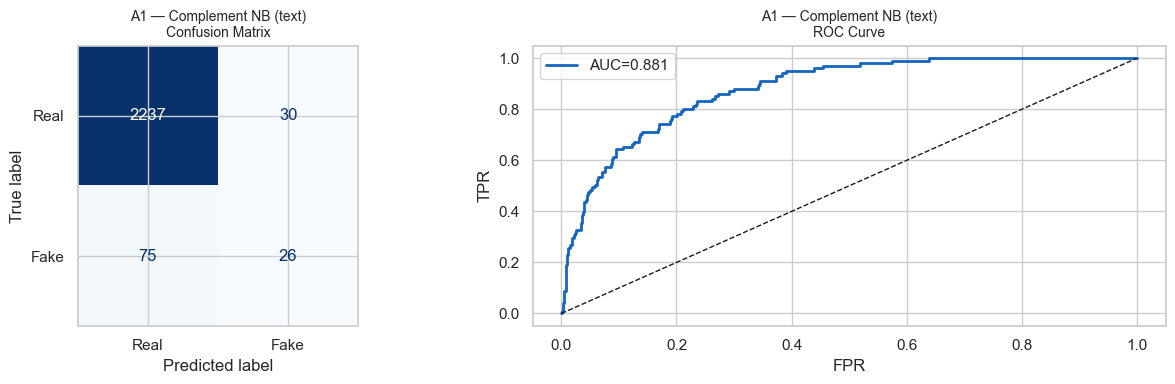

In [63]:
results_A = []

nb_a = ComplementNB()
nb_a.fit(Xa_train, y_train)
results_A.append(evaluate_model(nb_a, Xa_val, y_val, 'A1 — Complement NB (text)'))


### **A2 - Logistic Regression with balanced class weights**


  A2 — Logistic Regression (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99      2267
        Fake       0.97      0.39      0.55       101

    accuracy                           0.97      2368
   macro avg       0.97      0.69      0.77      2368
weighted avg       0.97      0.97      0.97      2368

ROC-AUC : 0.9684   |   Log Loss: 0.0826


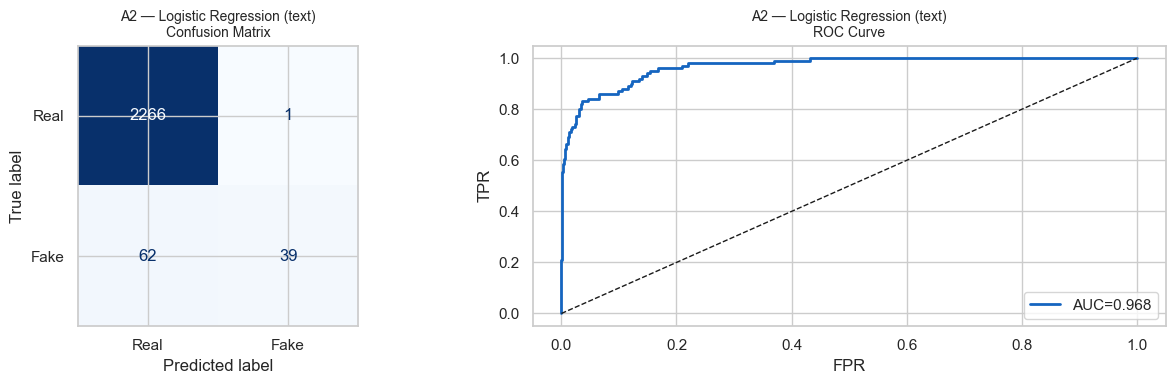

In [64]:
lr_a = LogisticRegression(C=1.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
lr_a.fit(Xa_train, y_train)
results_A.append(evaluate_model(lr_a, Xa_val, y_val, 'A2 — Logistic Regression (text)'))


### **A3 - Decision Tree**


  A3 — Decision Tree (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.94      0.96      2267
        Fake       0.35      0.69      0.47       101

    accuracy                           0.93      2368
   macro avg       0.67      0.82      0.71      2368
weighted avg       0.96      0.93      0.94      2368

ROC-AUC : 0.8212   |   Log Loss: 0.7656


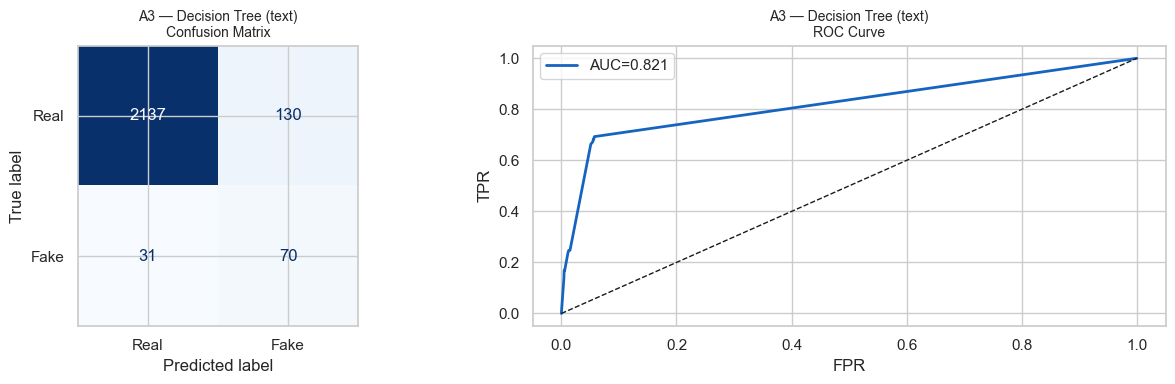

In [65]:
dt_a = DecisionTreeClassifier(max_depth=20, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE)
dt_a.fit(Xa_train, y_train)
results_A.append(evaluate_model(dt_a, Xa_val, y_val, 'A3 — Decision Tree (text)'))


### **A4 - Random Forest**


  A4 — Random Forest (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99      2267
        Fake       0.81      0.43      0.56       101

    accuracy                           0.97      2368
   macro avg       0.89      0.71      0.77      2368
weighted avg       0.97      0.97      0.97      2368

ROC-AUC : 0.9754   |   Log Loss: 0.1025


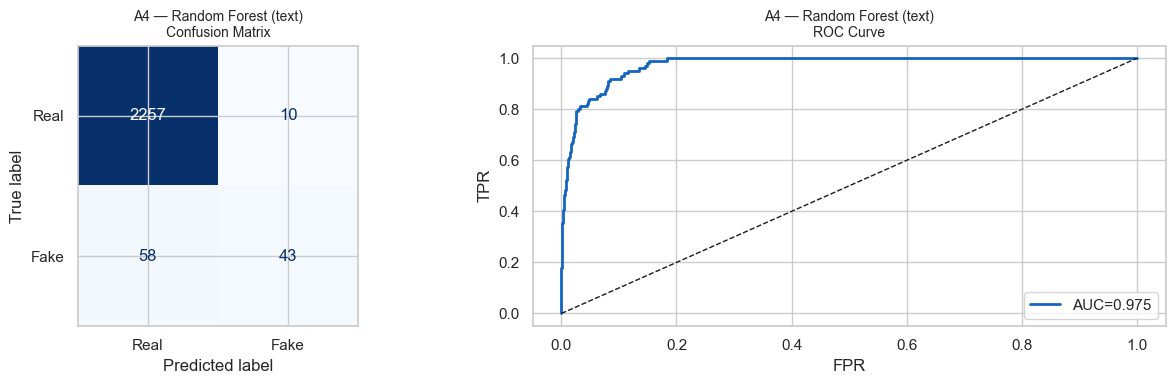

In [66]:
rf_a = RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_a.fit(Xa_train, y_train)
results_A.append(evaluate_model(rf_a, Xa_val, y_val, 'A4 — Random Forest (text)'))


### **A5 - Linear SVM (calibrated for probability output)**


  A5 — Linear SVM (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      2267
        Fake       0.96      0.65      0.78       101

    accuracy                           0.98      2368
   macro avg       0.97      0.83      0.88      2368
weighted avg       0.98      0.98      0.98      2368

ROC-AUC : 0.9789   |   Log Loss: 0.0542


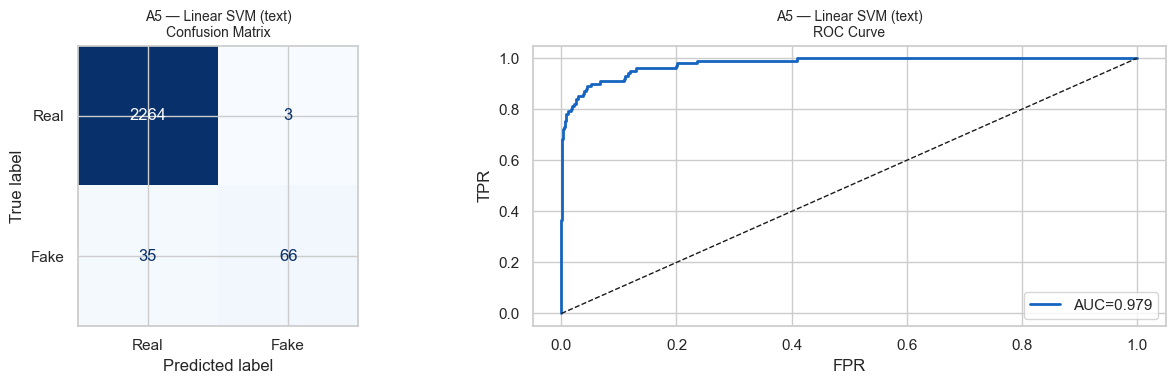

In [67]:
svm_a = CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=3000, class_weight='balanced',
              random_state=RANDOM_STATE), cv=3, method='sigmoid')
svm_a.fit(Xa_train, y_train)
results_A.append(evaluate_model(svm_a, Xa_val, y_val, 'A5 — Linear SVM (text)'))


### **A6 - XGBoost**


  A6 — XGBoost (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2267
        Fake       0.79      0.68      0.73       101

    accuracy                           0.98      2368
   macro avg       0.89      0.84      0.86      2368
weighted avg       0.98      0.98      0.98      2368

ROC-AUC : 0.9745   |   Log Loss: 0.0658


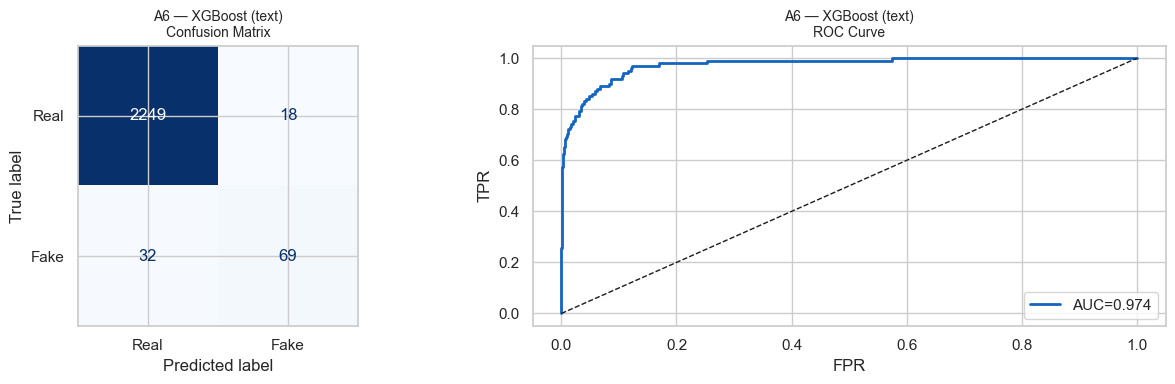

In [68]:
if XGBOOST_OK:
    neg_pos = int((y_train==0).sum() / (y_train==1).sum())
    xgb_a = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
        scale_pos_weight=neg_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_a.fit(Xa_train, y_train, eval_set=[(Xa_val, y_val)], verbose=False)
    results_A.append(evaluate_model(xgb_a, Xa_val, y_val, 'A6 — XGBoost (text)'))
else:
    print('XGBoost not available.')


### **A7 - LightGBM**


  A7 — LightGBM (text)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2267
        Fake       0.82      0.68      0.75       101

    accuracy                           0.98      2368
   macro avg       0.90      0.84      0.87      2368
weighted avg       0.98      0.98      0.98      2368

ROC-AUC : 0.9735   |   Log Loss: 0.0628


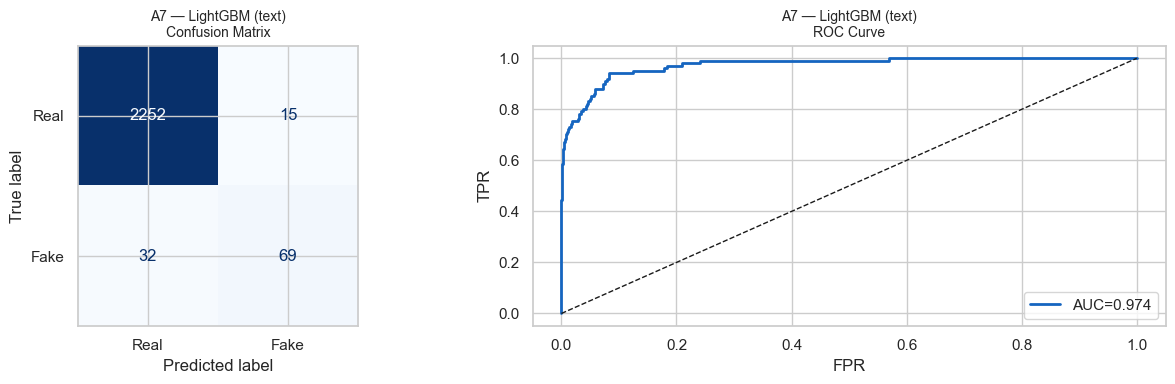

In [69]:
if LGBM_OK:
    lgbm_a = LGBMClassifier(n_estimators=400, max_depth=7, learning_rate=0.05,
        is_unbalance=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgbm_a.fit(Xa_train, y_train)
    results_A.append(evaluate_model(lgbm_a, Xa_val, y_val, 'A7 — LightGBM (text)'))
else:
    print('LightGBM not available.')


---
## **14. Model B - Hybrid Models (Text + Engineered Features)**

Trained on `Xb_train` (TF-IDF + numeric). May score higher on Kaggle but is less portable to datasets where metadata is unavailable.


### **B1 - Logistic Regression (hybrid)**


  B1 — Logistic Regression (hybrid)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.96      0.98      2267
        Fake       0.49      0.85      0.62       101

    accuracy                           0.96      2368
   macro avg       0.74      0.91      0.80      2368
weighted avg       0.97      0.96      0.96      2368

ROC-AUC : 0.9866   |   Log Loss: 0.1257


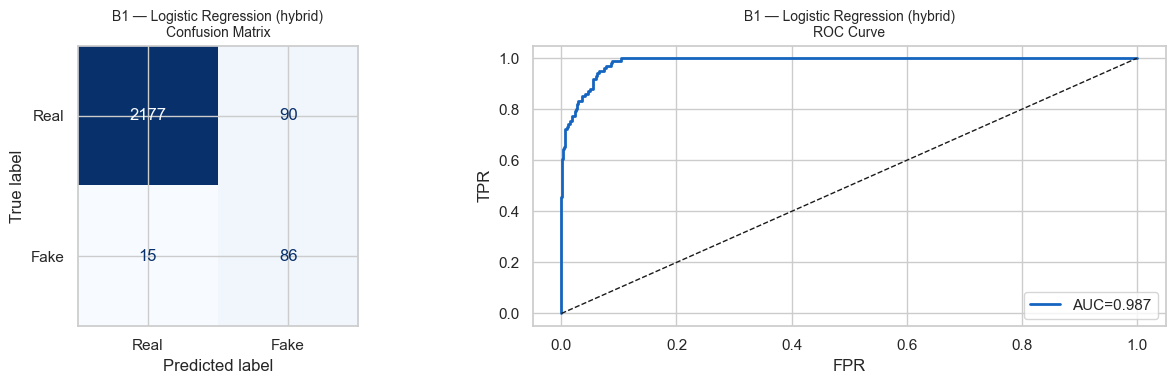

In [70]:
results_B = []

lr_b = LogisticRegression(C=1.0, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
lr_b.fit(Xb_train, y_train)
results_B.append(evaluate_model(lr_b, Xb_val, y_val, 'B1 — Logistic Regression (hybrid)'))


### **B2 - Hybrid Random Forest Classifier**


  B2 — Random Forest (hybrid)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99      2267
        Fake       0.82      0.42      0.55       101

    accuracy                           0.97      2368
   macro avg       0.90      0.71      0.77      2368
weighted avg       0.97      0.97      0.97      2368

ROC-AUC : 0.9770   |   Log Loss: 0.1008


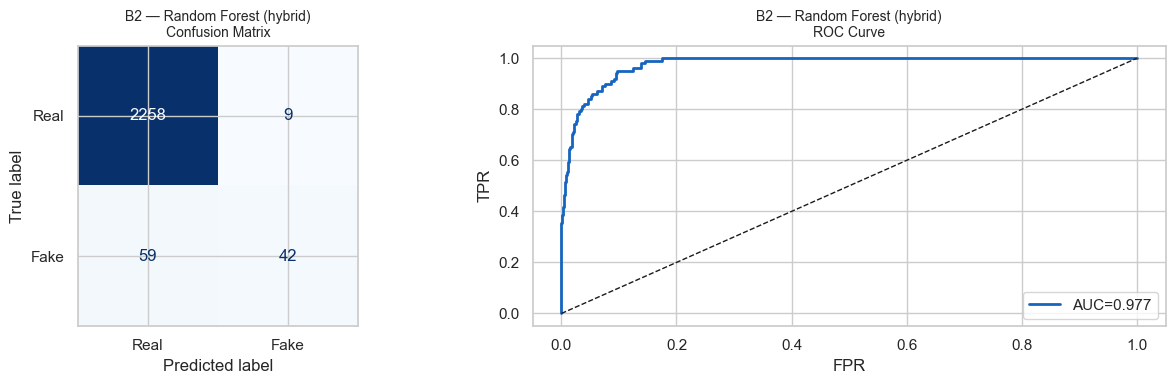

In [71]:
rf_b = RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_b.fit(Xb_train, y_train)
results_B.append(evaluate_model(rf_b, Xb_val, y_val, 'B2 — Random Forest (hybrid)'))


### **B3 - Calibrated Linear SVM (Hybrid)**


  B3 — Linear SVM (hybrid)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2267
        Fake       0.95      0.69      0.80       101

    accuracy                           0.99      2368
   macro avg       0.97      0.85      0.90      2368
weighted avg       0.98      0.99      0.98      2368

ROC-AUC : 0.9891   |   Log Loss: 0.0470


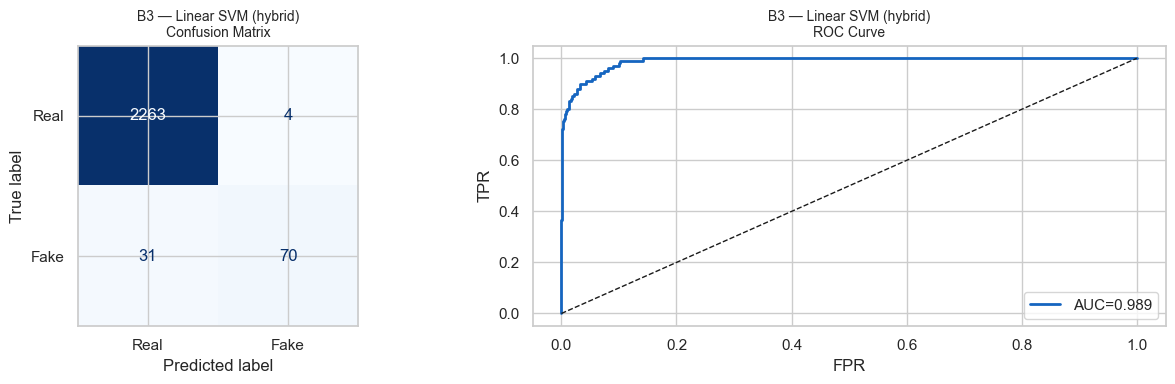

In [72]:
svm_b = CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=3000, class_weight='balanced',
              random_state=RANDOM_STATE), cv=3, method='sigmoid')
svm_b.fit(Xb_train, y_train)
results_B.append(evaluate_model(svm_b, Xb_val, y_val, 'B3 — Linear SVM (hybrid)'))


### **B4 - XGBoost (hybrid) & B5 - LightGBM (hybrid)**


  B4 — XGBoost (hybrid)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2267
        Fake       0.82      0.74      0.78       101

    accuracy                           0.98      2368
   macro avg       0.90      0.87      0.88      2368
weighted avg       0.98      0.98      0.98      2368

ROC-AUC : 0.9783   |   Log Loss: 0.0599


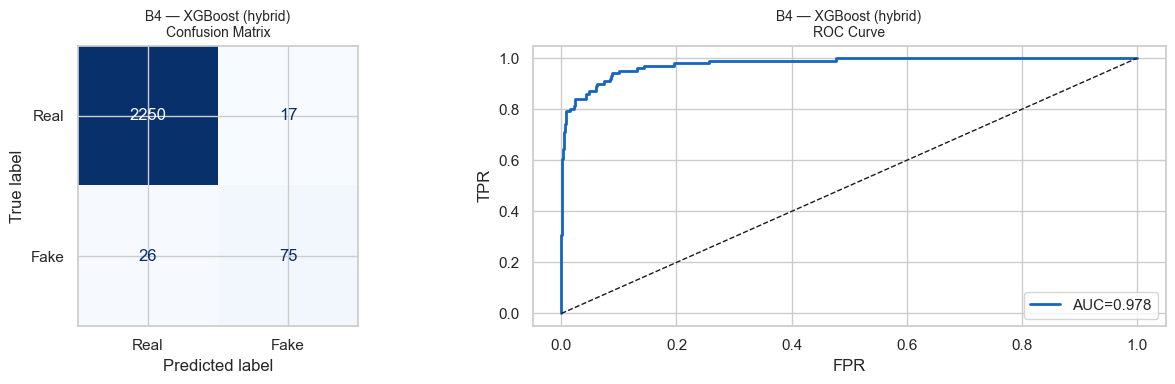


  B5 — LightGBM (hybrid)  |  threshold=0.50
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2267
        Fake       0.82      0.67      0.74       101

    accuracy                           0.98      2368
   macro avg       0.90      0.83      0.86      2368
weighted avg       0.98      0.98      0.98      2368

ROC-AUC : 0.9733   |   Log Loss: 0.0602


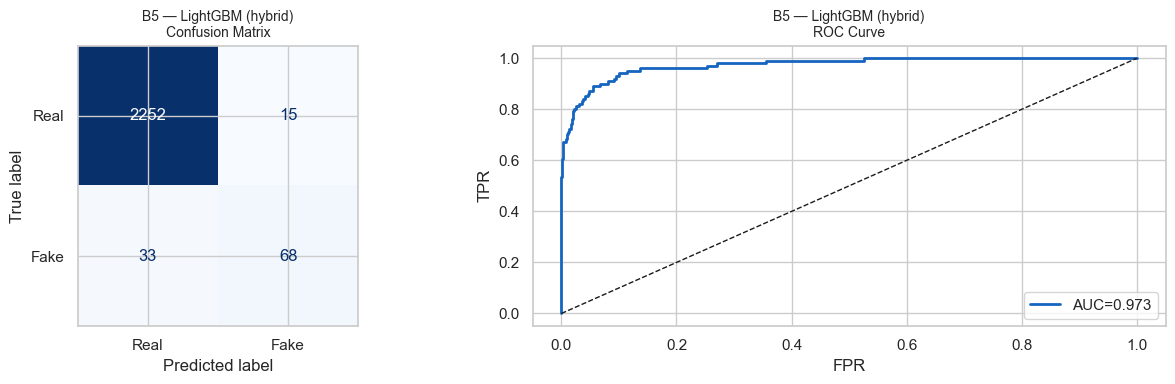

In [73]:
if XGBOOST_OK:
    xgb_b = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
        scale_pos_weight=neg_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_b.fit(Xb_train, y_train, eval_set=[(Xb_val, y_val)], verbose=False)
    results_B.append(evaluate_model(xgb_b, Xb_val, y_val, 'B4 — XGBoost (hybrid)'))

if LGBM_OK:
    lgbm_b = LGBMClassifier(n_estimators=400, max_depth=7, learning_rate=0.05,
        is_unbalance=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgbm_b.fit(Xb_train, y_train)
    results_B.append(evaluate_model(lgbm_b, Xb_val, y_val, 'B5 — LightGBM (hybrid)'))


---
## **15. Class Imbalance Handling**

### Strategy 1: `class_weight='balanced'` (used in all models above)

Scales loss contribution of each sample by the inverse of its class frequency. Zero extra computation; works natively with most sklearn classifiers.

### Strategy 2: SMOTE (demonstration on numeric features)

> SMOTE should never be applied before the train/test split. It is applied here **only to the training set**.  
> Applying SMOTE to high-dimensional TF-IDF sparse matrices is memory-intensive and not standard practice for text classification.


In [74]:
if SMOTE_OK:
    print('Class distribution BEFORE SMOTE:')
    print(pd.Series(y_train).value_counts().rename({0:'Real',1:'Fake'}))

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_num_sm, y_sm = smote.fit_resample(X_num_train.fillna(0), y_train)

    print('\nAfter SMOTE (numeric features only):')
    print(pd.Series(y_sm).value_counts().rename({0:'Real',1:'Fake'}))

    lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
    lr_smote.fit(X_num_sm, y_sm)
    print('\n--- LR on SMOTE numeric features ---')
    print(classification_report(y_val, lr_smote.predict(X_num_val.fillna(0)),
                                 target_names=['Real','Fake']))
    print('→ class_weight=balanced + TF-IDF is generally preferred for text tasks.')
else:
    print('imbalanced-learn not installed.  class_weight="balanced" used throughout.')


Class distribution BEFORE SMOTE:
fraudulent
Real    10579
Fake      471
Name: count, dtype: int64

After SMOTE (numeric features only):
fraudulent
Real    10579
Fake    10579
Name: count, dtype: int64

--- LR on SMOTE numeric features ---
              precision    recall  f1-score   support

        Real       0.98      0.82      0.90      2267
        Fake       0.15      0.71      0.25       101

    accuracy                           0.82      2368
   macro avg       0.57      0.77      0.57      2368
weighted avg       0.95      0.82      0.87      2368

→ class_weight=balanced + TF-IDF is generally preferred for text tasks.


---
## **16. Threshold Tuning**

Default threshold of 0.5 is arbitrary. We sweep [0.10, 0.90] on the validation set to find the threshold maximising Fake-class F1, then apply it once on the test set.


### **16.1 Probability Threshold Optimization**

Text-Only: Logistic Regression (A2)


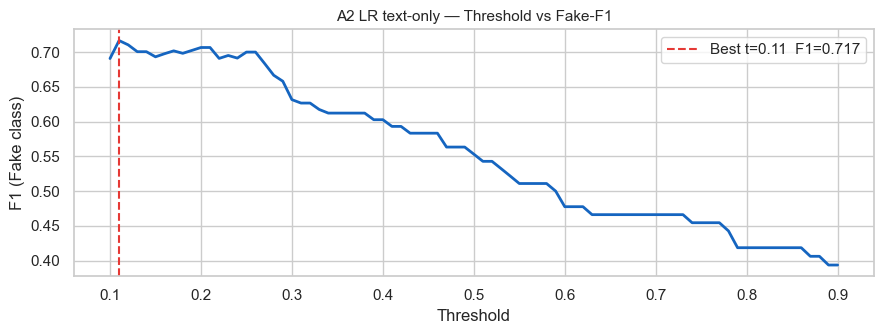

Best threshold: 0.11  |  Val Fake-F1: 0.7166

Text-Only: Random Forest (A4)


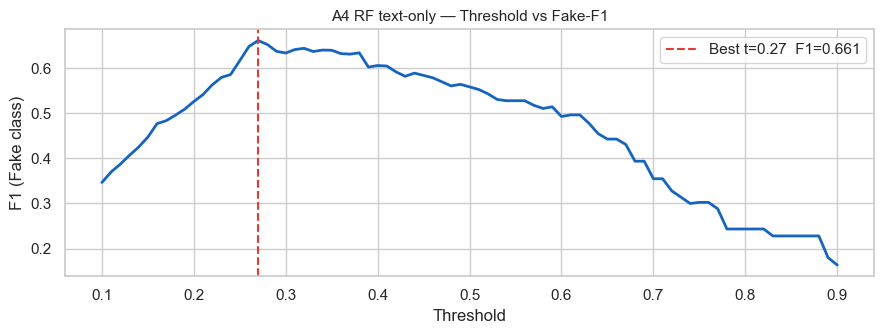

Best threshold: 0.27  |  Val Fake-F1: 0.6611

Hybrid: Logistic Regression (B1)


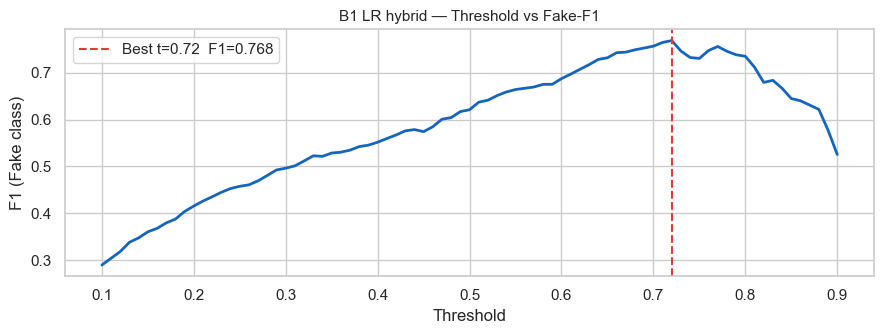

Best threshold: 0.72  |  Val Fake-F1: 0.7684

Hybrid: Random Forest (B2)


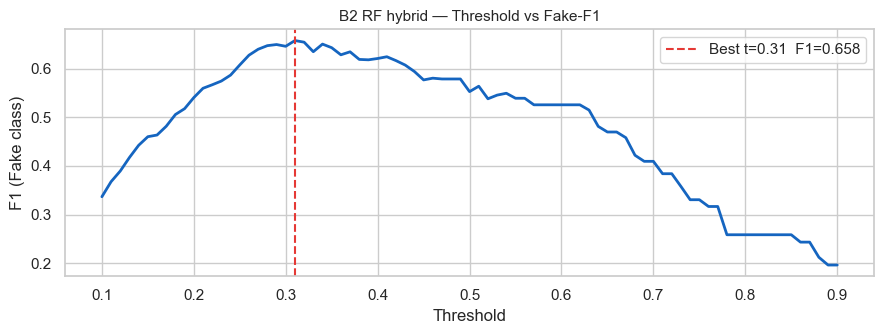

Best threshold: 0.31  |  Val Fake-F1: 0.6575


In [94]:
print('Text-Only: Logistic Regression (A2)')
thresh_lr_a = tune_threshold(lr_a, Xa_val, y_val, 'A2 LR text-only')

print('\nText-Only: Random Forest (A4)')
thresh_rf_a = tune_threshold(rf_a, Xa_val, y_val, 'A4 RF text-only')

print('\nHybrid: Logistic Regression (B1)')
thresh_lr_b = tune_threshold(lr_b, Xb_val, y_val, 'B1 LR hybrid')

print('\nHybrid: Random Forest (B2)')
thresh_rf_b = tune_threshold(rf_b, Xb_val, y_val, 'B2 RF hybrid')


### **16.2 Model Performance Comparison: Precision-Recall Analysis**

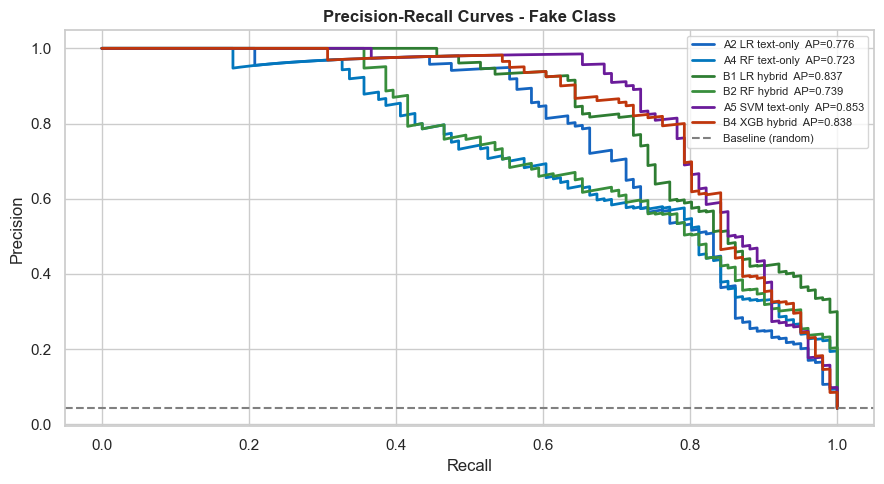

In [95]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_pairs = [
    (lr_a,  Xa_val, 'A2 LR text-only',  '#1565C0'),
    (rf_a,  Xa_val, 'A4 RF text-only',  '#0277BD'),
    (lr_b,  Xb_val, 'B1 LR hybrid',     '#2E7D32'),
    (rf_b,  Xb_val, 'B2 RF hybrid',     '#388E3C'),
    (svm_a, Xa_val, 'A5 SVM text-only', '#6A1B9A'),
]
if XGBOOST_OK: plot_pairs.append((xgb_b, Xb_val, 'B4 XGB hybrid', '#BF360C'))

for model, Xv, name, col in plot_pairs:
    p, r, _ = precision_recall_curve(y_val, get_proba(model, Xv))
    ap = average_precision_score(y_val, get_proba(model, Xv))
    ax.plot(r, p, lw=2, color=col, label=f'{name}  AP={ap:.3f}')

ax.axhline(y_val.mean(), color='grey', linestyle='--', label='Baseline (random)')
ax.set_title('Precision-Recall Curves - Fake Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('models/precision_recall_curves.png', dpi=120, bbox_inches='tight')
plt.show()


---
## **17. Cross-Validation**

Stratified 5-fold CV on train+val pool confirms results are **stable across different data splits**.


In [77]:
Xa_cv = sp_vstack([Xa_train, Xa_val])
Xb_cv = sp_vstack([Xb_train, Xb_val])
y_cv  = pd.concat([y_train, y_val]).reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_candidates = {
    'A2 LR text-only' : (lr_a,  Xa_cv),
    'A4 RF text-only' : (rf_a,  Xa_cv),
    'A5 SVM text-only': (svm_a, Xa_cv),
    'B1 LR hybrid'    : (lr_b,  Xb_cv),
    'B2 RF hybrid'    : (rf_b,  Xb_cv),
}
if XGBOOST_OK: cv_candidates['B4 XGB hybrid'] = (xgb_b, Xb_cv)
if LGBM_OK   : cv_candidates['B5 LGBM hybrid'] = (lgbm_b, Xb_cv)

cv_records = []
for name, (model, Xcv) in cv_candidates.items():
    print(f'  CV → {name} ...')
    scores = cross_validate(model, Xcv, y_cv, cv=skf, n_jobs=-1,
        scoring=['f1','roc_auc','recall','precision'])
    cv_records.append({'Model': name,
        'F1 mean':   round(scores['test_f1'].mean(),4),
        'F1 std':    round(scores['test_f1'].std(),4),
        'AUC mean':  round(scores['test_roc_auc'].mean(),4),
        'Rec mean':  round(scores['test_recall'].mean(),4),
        'Prec mean': round(scores['test_precision'].mean(),4)})

cv_df = pd.DataFrame(cv_records)
print('\n5-Fold CV Summary')
print(cv_df.to_string(index=False))
cv_df.to_csv('models/cv_results.csv', index=False)


  CV → A2 LR text-only ...
  CV → A4 RF text-only ...
  CV → A5 SVM text-only ...
  CV → B1 LR hybrid ...
  CV → B2 RF hybrid ...
  CV → B4 XGB hybrid ...
  CV → B5 LGBM hybrid ...

── 5-Fold CV Summary ─────────────────────────────────────────
           Model  F1 mean  F1 std  AUC mean  Rec mean  Prec mean
 A2 LR text-only   0.4221  0.1408    0.9712    0.7403     0.4700
 A4 RF text-only   0.5785  0.0564    0.9716    0.4459     0.8253
A5 SVM text-only   0.7846  0.0338    0.9794    0.6940     0.9044
    B1 LR hybrid   0.6045  0.0226    0.9811    0.8636     0.4657
    B2 RF hybrid   0.5905  0.0523    0.9724    0.4616     0.8212
   B4 XGB hybrid   0.7311  0.0294    0.9708    0.7167     0.7469
  B5 LGBM hybrid   0.7478  0.0247    0.9721    0.7080     0.7936


---
## **18. Model Comparison Table**

All Models - Validation Metrics (sorted by Fake F1):
                            Model  Precision_F  Recall_F   F1_F  ROC-AUC  Accuracy
         B3 — Linear SVM (hybrid)       0.9459    0.6931 0.8000   0.9891    0.9852
            B4 — XGBoost (hybrid)       0.8152    0.7426 0.7772   0.9783    0.9818
           A5 — Linear SVM (text)       0.9565    0.6535 0.7765   0.9789    0.9840
             A7 — LightGBM (text)       0.8214    0.6832 0.7459   0.9735    0.9802
           B5 — LightGBM (hybrid)       0.8193    0.6733 0.7391   0.9733    0.9797
              A6 — XGBoost (text)       0.7931    0.6832 0.7340   0.9745    0.9789
B1 — Logistic Regression (hybrid)       0.4886    0.8515 0.6209   0.9866    0.9557
        A4 — Random Forest (text)       0.8113    0.4257 0.5584   0.9754    0.9713
  A2 — Logistic Regression (text)       0.9750    0.3861 0.5532   0.9684    0.9734
      B2 — Random Forest (hybrid)       0.8235    0.4158 0.5526   0.9770    0.9713
        A3 — Decision Tree (text) 

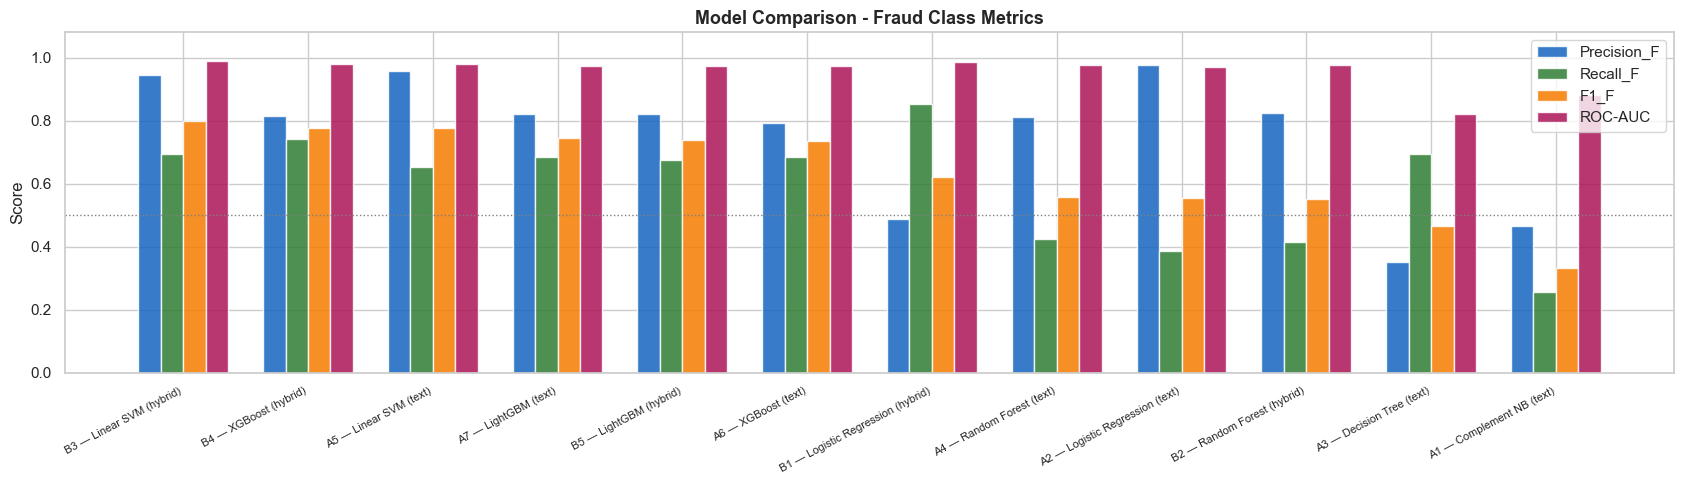

In [78]:
all_results = results_A + results_B
comp_df = pd.DataFrame(all_results).sort_values('F1_F', ascending=False).reset_index(drop=True)
print('All Models - Validation Metrics (sorted by Fake F1):')
print(comp_df[['Model','Precision_F','Recall_F','F1_F','ROC-AUC','Accuracy']].to_string(index=False))

metrics_plot = ['Precision_F','Recall_F','F1_F','ROC-AUC']
x = np.arange(len(comp_df)); w = 0.18
pal = ['#1565C0','#2E7D32','#F57C00','#AD1457']
fig, ax = plt.subplots(figsize=(17, 5))
for i, (m, c) in enumerate(zip(metrics_plot, pal)):
    ax.bar(x+i*w, comp_df[m], w, label=m, color=c, alpha=0.85, edgecolor='white')
ax.set_xticks(x+1.5*w)
ax.set_xticklabels(comp_df['Model'], rotation=28, ha='right', fontsize=8)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison - Fraud Class Metrics', fontsize=13, fontweight='bold')
ax.legend(); ax.axhline(0.5, color='grey', linestyle=':', lw=1)
plt.tight_layout()
plt.savefig('models/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
comp_df.to_csv('models/model_comparison.csv', index=False)


---
## **19. Explainability & Feature Importance**

Three levels of explanation:
1. **LR token weights** - most fraud-indicative vocabulary
2. **RF numeric importance** - which structured signals matter
3. **SHAP** - individual prediction attribution (optional)


### **19.1 LR token coefficients (text-only model A2)**

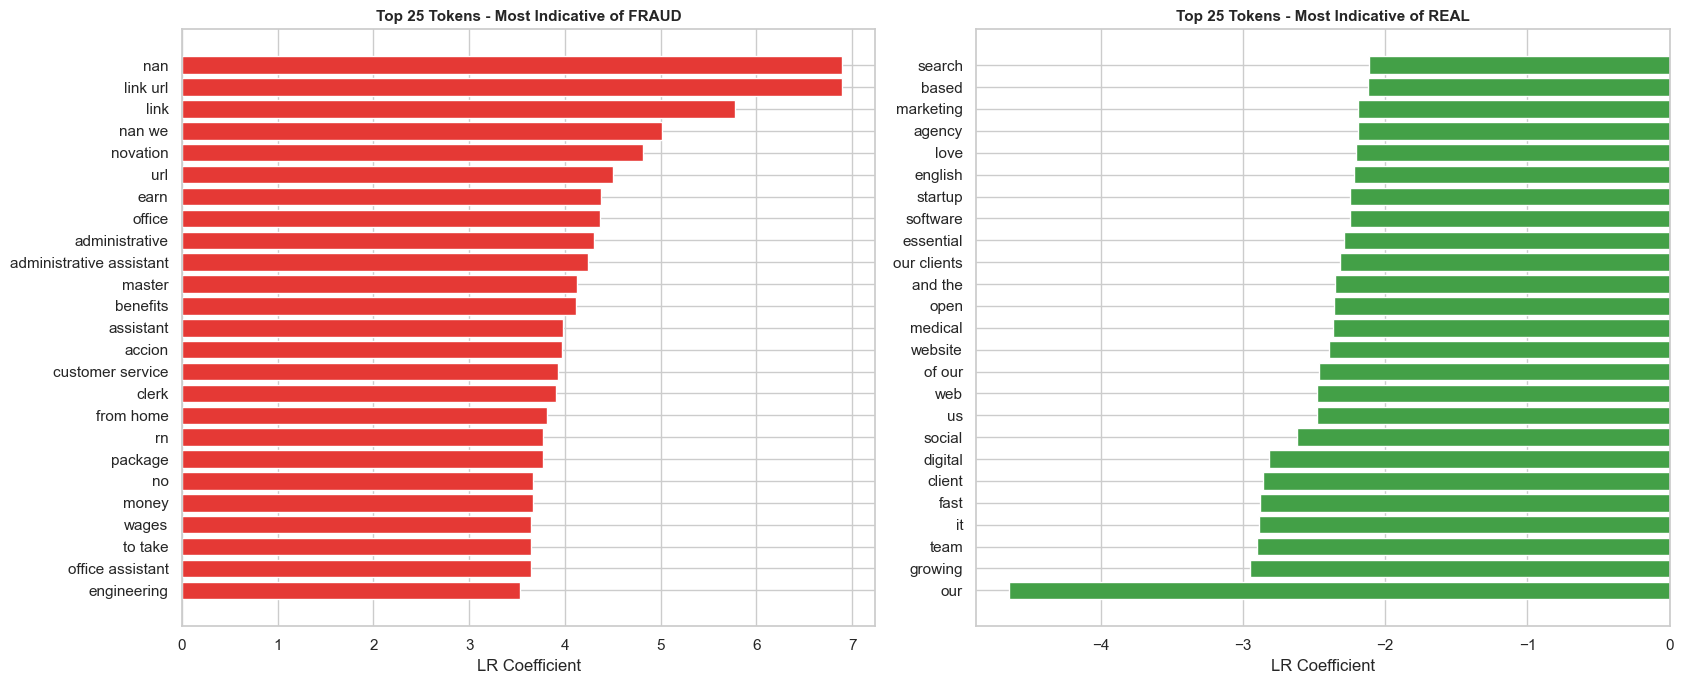

Top fraud tokens: ['nan', 'link url', 'link', 'nan we', 'novation', 'url', 'earn', 'office', 'administrative', 'administrative assistant', 'master', 'benefits']


In [79]:
vocab = np.array(tfidf.get_feature_names_out())
coef  = lr_a.coef_[0]
top_n = 25
top_i = np.argsort(coef)[-top_n:][::-1]
bot_i = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
axes[0].barh(vocab[top_i][::-1], coef[top_i][::-1], color='#E53935', edgecolor='white')
axes[0].set_title('Top 25 Tokens - Most Indicative of FRAUD', fontsize=11, fontweight='bold')
axes[0].set_xlabel('LR Coefficient')

axes[1].barh(vocab[bot_i], coef[bot_i], color='#43A047', edgecolor='white')
axes[1].set_title('Top 25 Tokens - Most Indicative of REAL', fontsize=11, fontweight='bold')
axes[1].set_xlabel('LR Coefficient')

plt.tight_layout()
plt.savefig('models/feat_importance_lr_tokens.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top fraud tokens:', vocab[top_i[:12]].tolist())


### **19.2 RF hybrid - numeric feature importance**

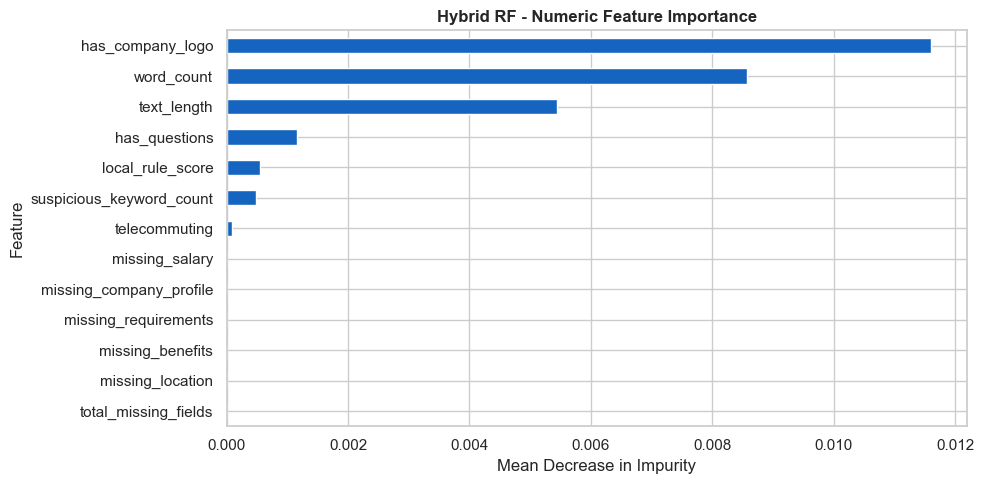

                 Feature  Importance
        has_company_logo    0.011605
              word_count    0.008570
             text_length    0.005446
           has_questions    0.001156
        local_rule_score    0.000547
suspicious_keyword_count    0.000487
           telecommuting    0.000092
          missing_salary    0.000000
 missing_company_profile    0.000000
    missing_requirements    0.000000
        missing_benefits    0.000000
        missing_location    0.000000
    total_missing_fields    0.000000


In [80]:
n_tfidf = Xa_train.shape[1]
rf_b_num_imp = rf_b.feature_importances_[n_tfidf:]
feat_names   = np.array(HYBRID_FEATURES[:len(rf_b_num_imp)])

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': rf_b_num_imp}
         ).sort_values('Importance', ascending=False)
ax = imp_df.plot(kind='barh', x='Feature', y='Importance',
                 figsize=(10,5), color='#1565C0', legend=False, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Hybrid RF - Numeric Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('models/feat_importance_rf_numeric.png', dpi=120, bbox_inches='tight')
plt.show()
print(imp_df.to_string(index=False))


### **19.3 SHAP**

Computing SHAP for XGBoost on numeric features ...


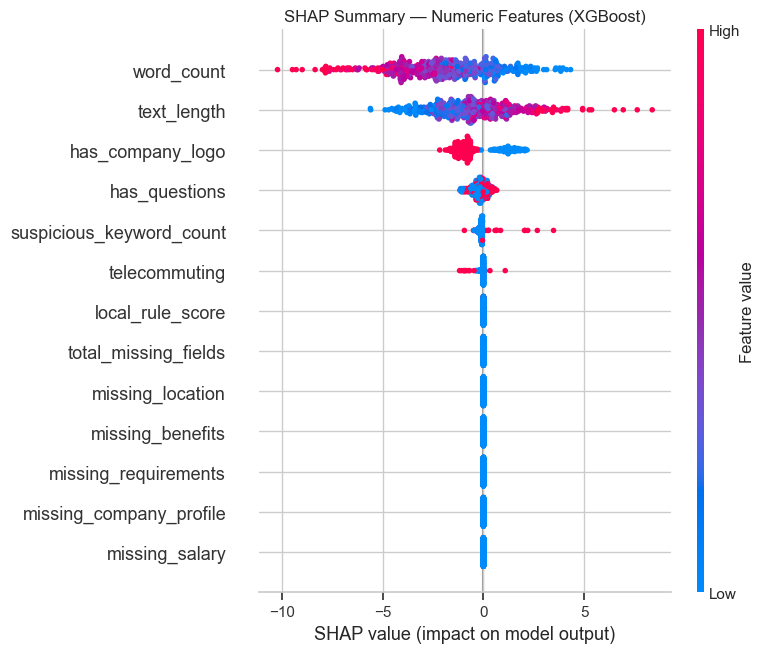

In [81]:
if SHAP_OK and XGBOOST_OK:
    print('Computing SHAP for XGBoost on numeric features ...')
    X_num_arr = X_num_val.fillna(0).values.astype(float)
    xgb_num = XGBClassifier(n_estimators=200, max_depth=5,
        scale_pos_weight=neg_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_num.fit(X_num_train.fillna(0), y_train)
    explainer   = shap.TreeExplainer(xgb_num)
    shap_values = explainer.shap_values(X_num_arr[:500])
    shap.summary_plot(shap_values, X_num_arr[:500],
        feature_names=HYBRID_FEATURES[:X_num_arr.shape[1]], show=False)
    plt.title('SHAP Summary — Numeric Features (XGBoost)', fontsize=12)
    plt.tight_layout()
    plt.savefig('models/shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('SHAP or XGBoost not available — using LR/RF importance instead.')


---
## **20. Final Risk Score Formula**

$$\text{final\_risk\_score} = 0.8 \times P_{\text{ML}} + 0.2 \times S_{\text{rules}}$$

| Final Score | Risk Level |
|---|---|
| 0–30% | Low |
| 31–70% | Medium |
| 71–100% | High |

The 80/20 weighting reflects the ML model's stronger discriminative power while preserving the transparent, language-aware rule signal.


In [82]:
ML_WEIGHT   = 0.80
RULE_WEIGHT = 0.20

def combine_risk_score(ml_prob: float, local_rule_score: float) -> float:
    return round(ML_WEIGHT * ml_prob + RULE_WEIGHT * local_rule_score, 4)

def risk_level(score: float) -> str:
    if score < 0.30: return 'Low'
    elif score < 0.70: return 'Medium'
    return 'High'

for ml_p, rule_s in [(0.05,0.0),(0.45,0.2),(0.82,0.6)]:
    fs = combine_risk_score(ml_p, rule_s)
    print(f'ML={ml_p:.2f}  Rule={rule_s:.2f}  → Final={fs:.2f}  → {risk_level(fs)}')


ML=0.05  Rule=0.00  → Final=0.04  → Low
ML=0.45  Rule=0.20  → Final=0.40  → Medium
ML=0.82  Rule=0.60  → Final=0.78  → High


---
## **21. Final Model Selection & Test Evaluation**

We select the best text-only and hybrid models from validation results, then evaluate **once on the test set**.


### 21.1 Model Selection and Registry
After evaluating multiple architectures, we systematically identify the top performers for each category (Text-Only and Hybrid).

* **Leaderboard Sorting:** We rank all trained models based on their **F1-Score** for the fraudulent class, as this harmonic mean ensures we are selecting models with the best balance of Precision and Recall.
* **Model Registry:** We maintain a dictionary-based registry (`MODEL_REG`) that maps descriptive names to the trained model objects. This allows for dynamic selection based on performance metrics rather than hardcoding a specific algorithm.
* **Final Threshold Calibration:** For the "Champion" of each category, we run one final pass of `tune_threshold`. This ensures that even our best models are specifically "zeroed in" on the optimal probability cutoff before they face the unseen test data.

In [83]:
df_A = pd.DataFrame(results_A).sort_values('F1_F', ascending=False)
df_B = pd.DataFrame(results_B).sort_values('F1_F', ascending=False)

best_A_name = df_A.iloc[0]['Model']
best_B_name = df_B.iloc[0]['Model']
print(f'Best TEXT-ONLY: {best_A_name}  F1={df_A.iloc[0]["F1_F"]}  AUC={df_A.iloc[0]["ROC-AUC"]}')
print(f'Best HYBRID   : {best_B_name}  F1={df_B.iloc[0]["F1_F"]}  AUC={df_B.iloc[0]["ROC-AUC"]}')

MODEL_REG_A = {'A1 — Complement NB (text)': nb_a,
               'A2 — Logistic Regression (text)': lr_a,
               'A3 — Decision Tree (text)': dt_a,
               'A4 — Random Forest (text)': rf_a,
               'A5 — Linear SVM (text)': svm_a}
MODEL_REG_B = {'B1 — Logistic Regression (hybrid)': lr_b,
               'B2 — Random Forest (hybrid)': rf_b,
               'B3 — Linear SVM (hybrid)': svm_b}
if XGBOOST_OK:
    MODEL_REG_A['A6 — XGBoost (text)'] = xgb_a
    MODEL_REG_B['B4 — XGBoost (hybrid)'] = xgb_b
if LGBM_OK:
    MODEL_REG_A['A7 — LightGBM (text)'] = lgbm_a
    MODEL_REG_B['B5 — LightGBM (hybrid)'] = lgbm_b

best_model_A = MODEL_REG_A.get(best_A_name, lr_a)
best_model_B = MODEL_REG_B.get(best_B_name, lr_b)
best_thresh_A = tune_threshold(best_model_A, Xa_val, y_val,
    f'FINAL-A {type(best_model_A).__name__}', plot=False)
best_thresh_B = tune_threshold(best_model_B, Xb_val, y_val,
    f'FINAL-B {type(best_model_B).__name__}', plot=False)


Best TEXT-ONLY: A5 — Linear SVM (text)  F1=0.7765  AUC=0.9789
Best HYBRID   : B3 — Linear SVM (hybrid)  F1=0.8  AUC=0.9891
Best threshold: 0.37  |  Val Fake-F1: 0.8043
Best threshold: 0.42  |  Val Fake-F1: 0.8222


### **21.2 Final Performance Validation: The Test Set**
We perform a single, final evaluation on our "Hold-out" test set—data that the models have never seen during training or hyperparameter tuning.

* **Integrity Check:** By evaluating only at the very end, we obtain an unbiased estimate of how the model will perform in the real world.
* **Text-Only vs. Hybrid:** We compare our best "Pure NLP" architecture against our "Metadata-Enhanced" hybrid architecture.
* **The Deployment Logic:**
    * **Simplicity First:** If the Text-Only model performs within 3% of the Hybrid model, we favor it for its portability and ease of use on any job platform.
    * **Performance First:** If the Hybrid model shows a significant lead, we recommend it as the primary defense against sophisticated fraud, provided metadata (like logos and questions) is available.

  FINAL TEST - Text-Only Model

  FINAL TEXT-ONLY — CalibratedClassifierCV  |  threshold=0.37
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2268
        Fake       0.88      0.78      0.83       101

    accuracy                           0.99      2369
   macro avg       0.93      0.89      0.91      2369
weighted avg       0.99      0.99      0.99      2369

ROC-AUC : 0.9885   |   Log Loss: 0.0458


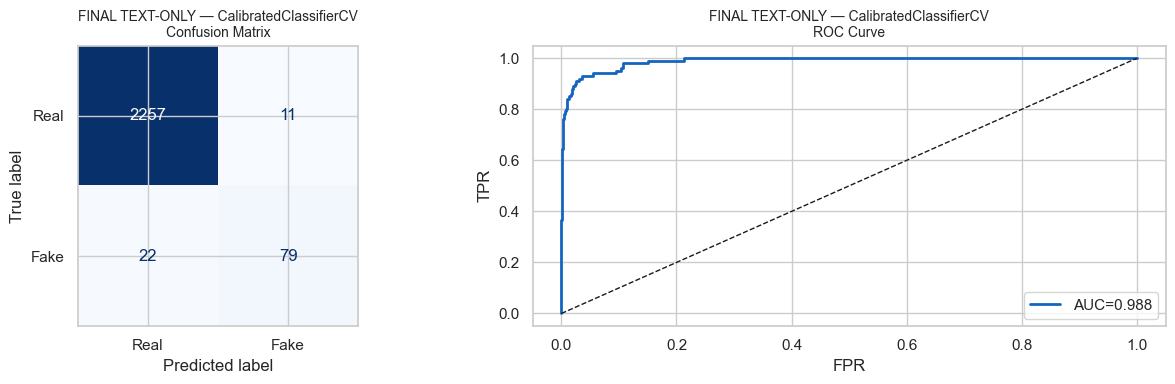

  FINAL TEST - Hybrid Model

  FINAL HYBRID — CalibratedClassifierCV  |  threshold=0.42
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2268
        Fake       0.89      0.79      0.84       101

    accuracy                           0.99      2369
   macro avg       0.94      0.89      0.92      2369
weighted avg       0.99      0.99      0.99      2369

ROC-AUC : 0.9903   |   Log Loss: 0.0436


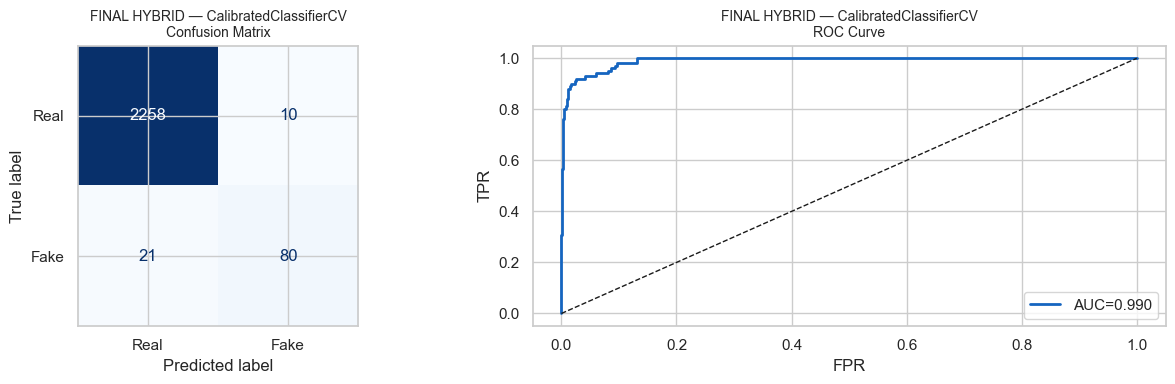


Final Test Comparison
                                   Model  Precision_F  Recall_F   F1_F  ROC-AUC  Accuracy
FINAL TEXT-ONLY — CalibratedClassifierCV       0.8778    0.7822 0.8272   0.9885    0.9861
   FINAL HYBRID — CalibratedClassifierCV       0.8889    0.7921 0.8377   0.9903    0.9869

→ Text-Only model recommended for deployment (portable, robust, near-equal performance).


In [96]:
print('  FINAL TEST - Text-Only Model')
final_A = evaluate_model(best_model_A, Xa_test, y_test,
    model_name=f'FINAL TEXT-ONLY — {type(best_model_A).__name__}',
    threshold=best_thresh_A)

print('  FINAL TEST - Hybrid Model')
final_B = evaluate_model(best_model_B, Xb_test, y_test,
    model_name=f'FINAL HYBRID — {type(best_model_B).__name__}',
    threshold=best_thresh_B)

final_compare = pd.DataFrame([final_A, final_B])
print('\nFinal Test Comparison')
print(final_compare[['Model','Precision_F','Recall_F','F1_F','ROC-AUC','Accuracy']].to_string(index=False))

if final_A['F1_F'] >= final_B['F1_F'] * 0.97:
    print('\n→ Text-Only model recommended for deployment (portable, robust, near-equal performance).')
else:
    print('\n→ Hybrid model significantly better; use it when metadata is available.')


---
## **22. Save All Artifacts**

In [98]:
joblib.dump(best_model_A, 'models/model_text_only.joblib');   print('model_text_only.joblib')
joblib.dump(best_model_B, 'models/model_hybrid.joblib');      print('model_hybrid.joblib')
joblib.dump(tfidf,        'models/tfidf_vectorizer.joblib');   print('tfidf_vectorizer.joblib')
joblib.dump(scaler,       'models/numeric_scaler.joblib');     print('numeric_scaler.joblib')

config = {
    'model_text_only' : type(best_model_A).__name__,
    'model_hybrid'    : type(best_model_B).__name__,
    'threshold_text'  : float(best_thresh_A),
    'threshold_hybrid': float(best_thresh_B),
    'ml_weight'       : ML_WEIGHT,
    'rule_weight'     : RULE_WEIGHT,
    'hybrid_features' : HYBRID_FEATURES,
    'translate_fields': TRANSLATE_FIELDS,
    'tfidf_vocab_size': len(tfidf.vocabulary_),
}
with open('models/model_config.json','w') as f: json.dump(config, f, indent=2)
print('model_config.json')

with open('models/suspicious_keywords.json','w',encoding='utf-8') as f:
    json.dump({'en':SUSPICIOUS_KW_EN,'ru':SUSPICIOUS_KW_RU,'kz':SUSPICIOUS_KW_KZ},
              f, indent=2, ensure_ascii=False)
print('suspicious_keywords.json')

with open('models/kz_column_map.json','w',encoding='utf-8') as f:
    json.dump(KZ_COLUMN_MAP, f, indent=2, ensure_ascii=False)
print('kz_column_map.json')

comp_df.to_csv('models/model_comparison.csv', index=False); print('model_comparison.csv')
cv_df.to_csv('models/cv_results.csv', index=False);         print('cv_results.csv')
pd.DataFrame([final_A,final_B]).to_csv('models/final_test_metrics.csv', index=False)
print('final_test_metrics.csv')
print('\nAll artifacts saved to models/')


model_text_only.joblib
model_hybrid.joblib
tfidf_vectorizer.joblib
numeric_scaler.joblib
model_config.json
suspicious_keywords.json
kz_column_map.json
model_comparison.csv
cv_results.csv
final_test_metrics.csv

All artifacts saved to models/


---
## **23. Website Integration Functions**

Complete, production-ready inference API for the TrustJob KZ Streamlit / FastAPI backend. **Minimum input: title + description.**


### **23.1 Deployment State: Artifact Loading and Configuration**
We transition to the **Inference Engine** by reloading all serialized components from the training phase.

* **Serialized Weights:** We load the champion models and the numeric scaler to ensure feature consistency.
* **Linguistic Memory:** The TF-IDF vectorizer is reloaded to maintain the exact vocabulary mappings (2,000 features) used during learning.
* **Dynamic Configuration:**
    * **Thresholds:** Probability cutoffs optimized for F1-score are applied.
    * **Heuristic Weights:** The balance between Machine Learning confidence and Rule-based triggers is established.
    * **Multilingual Support:** The system loads suspicious keywords in English, Russian, and Kazakh to support regional job market analysis.

In [99]:
import re, json, warnings, joblib
import numpy as np, pandas as pd
from scipy.sparse import hstack, csr_matrix
warnings.filterwarnings('ignore')

_MODEL_TEXT  = joblib.load('models/model_text_only.joblib')
_MODEL_HYB   = joblib.load('models/model_hybrid.joblib')
_TFIDF       = joblib.load('models/tfidf_vectorizer.joblib')
_SCALER      = joblib.load('models/numeric_scaler.joblib')
with open('models/model_config.json') as f: _CFG = json.load(f)
_THRESH_TEXT = _CFG['threshold_text']
_THRESH_HYB  = _CFG['threshold_hybrid']
_ML_W        = _CFG['ml_weight']
_RULE_W      = _CFG['rule_weight']
_HYB_FEATS   = _CFG['hybrid_features']
with open('models/suspicious_keywords.json', encoding='utf-8') as f: _KWD = json.load(f)
_ALL_KW = _KWD['en'] + _KWD['ru'] + _KWD.get('kz',[])

print('Artifacts reloaded.')


Artifacts reloaded.


### **23.2 Real-time Inference and Explainability**
We transition from model evaluation to a functional inference pipeline. These utilities allow the system to process individual job postings and generate human-readable risk reports.

* **Logic:**
    1. **Normalize:** Clean and translate text to match training distribution.
    2. **Quantify:** Generate a numeric feature vector identical to the training set.
    3. **Predict:** Calculate a fraud probability using the "Champion" model.
    4. **Explain:** Cross-reference ML confidence with heuristic rules to provide a transparent "Reason for Flagging."
* **Outcome:** A system that provides not just a classification, but an actionable "Risk Level" (Low, Medium, High) with supporting evidence.

In [100]:

def _clean(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def _translate_field(text, enabled):
    if not enabled or not isinstance(text, str): return text
    try:
        if TRANSLATE_OK:
            from deep_translator import GoogleTranslator
            return GoogleTranslator(source='auto', target='en').translate(text) or text
    except Exception:
        pass
    return text


def _rule_result(text):
    tl = text.lower()
    found = list(set(kw for kw in _ALL_KW if kw in tl))
    return {'suspicious_keyword_count': len(found),
            'local_rule_score': round(min(len(found)/5.0,1.0),4),
            'detected_phrases': found}


def _get_proba(model, X):
    if hasattr(model, 'predict_proba'): return float(model.predict_proba(X)[0,1])
    from sklearn.preprocessing import minmax_scale
    return float(minmax_scale(model.decision_function(X).reshape(-1,1))[0,0])


def _risk_lv(score):
    if score < 0.30: return 'Low'
    elif score < 0.70: return 'Medium'
    return 'High'


def _num_row(job):
    raw = ' '.join(str(job.get(c,'')) for c in
          ['title','company_profile','description','requirements','benefits'])
    cl  = _clean(raw); rule = _rule_result(raw)
    base = {
        'text_length': len(cl), 'word_count': len(cl.split()),
        'missing_salary'          : int(not bool(job.get('salary_range',''))),
        'missing_company_profile' : int(not bool(job.get('company_profile',''))),
        'missing_requirements'    : int(not bool(job.get('requirements',''))),
        'missing_benefits'        : int(not bool(job.get('benefits',''))),
        'missing_location'        : int(not bool(job.get('location',''))),
        'total_missing_fields'    : sum(int(not bool(job.get(c,'')))
            for c in ['salary_range','company_profile','requirements','benefits']),
        'suspicious_keyword_count': rule['suspicious_keyword_count'],
        'local_rule_score'        : rule['local_rule_score'],
        'has_company_logo': int(bool(job.get('has_company_logo',0))),
        'has_questions'   : int(bool(job.get('has_questions',0))),
        'telecommuting'   : int(bool(job.get('telecommuting',0))),
    }
    return pd.DataFrame([{k: base.get(k,0) for k in _HYB_FEATS}])


def _explain(job, ml_prob, rule_res):
    lines = []
    if not bool(job.get('company_profile','')): lines.append('No company profile provided.')
    if not bool(job.get('salary_range','')):    lines.append('Salary range is missing.')
    if not bool(job.get('requirements','')):    lines.append('No requirements section.')
    if not job.get('has_company_logo',0):       lines.append('No company logo.')
    miss = sum(int(not bool(job.get(c,'')))
               for c in ['salary_range','company_profile','requirements','benefits'])
    if miss >= 3: lines.append(f'{miss}/4 key fields are empty.')
    if rule_res['suspicious_keyword_count'] > 0:
        lines.append(
            f'{rule_res["suspicious_keyword_count"]} suspicious phrase(s): ' +
            ', '.join(f'"{p}"' for p in rule_res['detected_phrases'][:5]))
    if ml_prob > 0.70: lines.append('ML model is highly confident this posting is fraudulent.')
    return ' | '.join(lines) if lines else 'No strong suspicious signals detected.'


print('Internal utilities defined.')


Internal utilities defined.


### **23.3 Real-Time Prediction Engine: The `predict_single_job` Interface**
The project concludes with a robust inference function designed for production use. It integrates text processing, heuristic rules, and machine learning into a single decision-making unit.

* **Dual-Track Processing:**
    * **Heuristic Track:** Scans raw input for known suspicious phrases (English/Russian/Kazakh).
    * **ML Track:** Vectorizes cleaned text and applies the "Champion" model to calculate fraud probability.
* **Smart Weighting:** The final risk score is a composite metric, ensuring that even if the ML model is uncertain, strong rule-based "Red Flags" will still trigger a high-risk warning.
* **Explainability:** Returns a dictionary that explicitly lists detected phrases and explains the logic behind the "Fake" or "Real" label.

In [112]:
def predict_single_job(job_data: dict,
                       translate_to_english: bool = 'auto',
                       use_hybrid: bool = False) -> dict:
    sample_text = str(job_data.get('description', '')) + str(job_data.get('title', ''))
    
    if translate_to_english == 'auto':
        lang = detect_language(sample_text)
        should_translate = (lang == 'ru')
    else:
        should_translate = bool(translate_to_english)
    
    job = {
        k: (_translate_field(v, should_translate)
            if k in TRANSLATE_FIELDS and isinstance(v, str) else v)
        for k, v in job_data.items()
    }
    """
    translate_to_english:
        'auto'  — автоопределение языка (рекомендуется)
        True    — всегда переводить
        False   — никогда не переводить
    """
    """
    Predict whether a single job posting is fake.

    Parameters
    ----------
    job_data : dict
        Minimum keys : 'title', 'description'
        Optional keys: 'company_profile', 'requirements', 'benefits',
                       'salary_range', 'location', 'employment_type',
                       'has_company_logo', 'has_questions', 'telecommuting'
    translate_to_english : bool
        Translate Russian/Kazakh text fields before prediction.
        Requires deep-translator. If unavailable, returns original text.
    use_hybrid : bool
        Use hybrid model (text + features). Default False = text-only (recommended).

    Returns
    -------
    dict:
        prediction                 : 'Real' | 'Fake'
        ml_fraud_probability       : float [0,1]
        local_rule_score           : float [0,1]
        final_risk_score           : float [0,1]
        risk_level                 : 'Low' | 'Medium' | 'High'
        detected_suspicious_phrases: list[str]
        explanation                : str
    """
    TFIELDS = _CFG.get('translate_fields',
        ['title','description','requirements','company_profile','benefits'])

    # 1. Optional translation
    job = {k: (_translate_field(v, translate_to_english)
               if k in TFIELDS and isinstance(v, str) else v)
           for k, v in job_data.items()}

    # 2. Clean combined text
    combined = _clean(' '.join(str(job.get(c,'')) for c in
        ['title','company_profile','description','requirements','benefits']))

    # 3. Local rule score on ORIGINAL text (catches RU/KZ phrases before translation)
    # ВАЖНО: rule_result запускаем на ОРИГИНАЛЬНОМ тексте (до перевода)
# чтобы поймать русские фразы "без опыта", "предоплата" и т.д.
    raw_original = ' '.join(str(job_data.get(c,'')) for c in
               ['title','description','requirements','company_profile','benefits'])
    rule_res = _rule_result(raw_original)

    # 4. Vectorise
    X_tfidf = _TFIDF.transform([combined])

    # 5. Choose model + feature matrix
    if use_hybrid:
        num_df = _num_row(job)
        X_in   = hstack([X_tfidf, csr_matrix(_SCALER.transform(num_df.fillna(0)))])
        model, thresh = _MODEL_HYB, _THRESH_HYB
    else:
        X_in, model, thresh = X_tfidf, _MODEL_TEXT, _THRESH_TEXT

    # 6. ML probability + final score
    ml_prob     = _get_proba(model, X_in)
    final_score = float(_ML_W * ml_prob + _RULE_W * rule_res['local_rule_score'])

    return {
        'prediction'                 : 'Fake' if ml_prob >= thresh else 'Real',
        'ml_fraud_probability'       : round(ml_prob, 4),
        'local_rule_score'           : rule_res['local_rule_score'],
        'final_risk_score'           : round(final_score, 4),
        'risk_level'                 : _risk_lv(final_score),
        'detected_suspicious_phrases': rule_res['detected_phrases'],
        'explanation'                : _explain(job_data, ml_prob, rule_res),
    }


print('predict_single_job() defined.')


predict_single_job() defined.


### **23.4 Batch Inference and Audit Pipeline**
To facilitate the analysis of large datasets, we implement a batch processing wrapper. This function automates the end-to-end flow from raw file ingestion to final risk reporting.

* **Standardization:** Automatically maps diverse data sources (e.g., local Kazakhstan job portals vs. Kaggle datasets) to a unified internal schema.
* **Enrichment:** Appends seven new diagnostic columns to the original data, including `final_risk_score`, `risk_level`, and a natural language `explanation`.
* **Scalability:** Enables rapid auditing of job platforms to identify systemic fraud trends or clusters of suspicious postings.

In [113]:
def predict_batch_jobs(df_or_path,
                       source: str = 'kazakhstan',
                       translate_to_english = 'auto',  
                       use_hybrid: bool = False) -> pd.DataFrame:
    """
    Batch prediction from a DataFrame or CSV file path.

    Parameters
    ----------
    df_or_path           : pd.DataFrame or str path to CSV
    source               : 'kaggle' | 'kazakhstan' | 'user_input'
    translate_to_english : bool
    use_hybrid           : bool

    Returns
    -------
    Original DataFrame with prediction columns appended.
    """
    raw = pd.read_csv(df_or_path) if isinstance(df_or_path, str) else df_or_path.copy()
    std = standardize_job_dataframe(raw, source=source)
    results = [predict_single_job(r.to_dict(),
                   translate_to_english=translate_to_english,
                   use_hybrid=use_hybrid)
               for _, r in std.iterrows()]
    return pd.concat([raw.reset_index(drop=True), pd.DataFrame(results)], axis=1)


print('predict_batch_jobs() defined.')


predict_batch_jobs() defined.


### **23.5 System Validation: Real-world Test Scenarios**
We validate the final inference engine by feeding it three distinct archetypes: a typical English-language "Easy Money" scam, a localized Russian-language scam, and a legitimate professional posting.

* **Multilingual Resilience:** The system successfully identifies the Russian scam by utilizing its localized heuristic dictionary, demonstrating protection even when NLP vectors might be less certain.
* **Structural Signal Strength:** The legitimate job posting is correctly classified as "Low Risk" due to its high text density, detailed requirements, and metadata completeness (logo, salary, questions).
* **Transparent Decision Making:** Every prediction is accompanied by an `explanation` field, transforming the "Black Box" of Machine Learning into a transparent tool for security auditing.

In [103]:
FAKE_EN = {
    'title': 'Make Money Fast — Work From Home!',
    'company_profile': '',
    'description': 'No experience needed! Earn $5000/week guaranteed. Apply via WhatsApp.',
    'requirements': '', 'benefits': '', 'salary_range': '',
    'location': '', 'has_company_logo': 0,
}

FAKE_RU = {
    'title': 'Работа на дому — без опыта! Срочный набор',
    'company_profile': '',
    'description': 'Ежедневная оплата. Предоплата за обучение. Пишите в WhatsApp!',
    'requirements': '', 'benefits': '',
    'salary_range': '', 'location': 'Алматы',
}

REAL_EN = {
    'title': 'Senior Python Developer',
    'company_profile': 'FinTech startup in Almaty with 200+ employees.',
    'description': 'Join our backend team to build scalable financial APIs.',
    'requirements': 'Python 3.10+, FastAPI, PostgreSQL, Docker, 3+ years.',
    'benefits': '28 days PTO, health insurance, equity, remote-friendly.',
    'salary_range': '800000-1200000 KZT',
    'location': 'Almaty, Kazakhstan',
    'has_company_logo': 1, 'has_questions': 1,
}

for label, job in [
    ('EN FAKE', FAKE_EN),
    ('RU FAKE', FAKE_RU),
    ('Real',     REAL_EN),
]:
    r = predict_single_job(job, translate_to_english=False, use_hybrid=False)
    print(f'\n── {label} ──────────────────────────────────')
    for k, v in r.items():
        print(f'  {k:30}: {v}')



── EN FAKE ──────────────────────────────────
  prediction                    : Fake
  ml_fraud_probability          : 0.9495
  local_rule_score              : 0.6
  final_risk_score              : 0.8796
  risk_level                    : High
  detected_suspicious_phrases   : ['no experience needed', 'work from home', 'whatsapp']
  explanation                   : No company profile provided. | Salary range is missing. | No requirements section. | No company logo. | 4/4 key fields are empty. | 3 suspicious phrase(s): "no experience needed", "work from home", "whatsapp" | ML model is highly confident this posting is fraudulent.

── RU FAKE ──────────────────────────────────
  prediction                    : Real
  ml_fraud_probability          : 0.0187
  local_rule_score              : 1.0
  final_risk_score              : 0.215
  risk_level                    : Low
  detected_suspicious_phrases   : ['предоплата', 'пишите в whatsapp', 'оплата за обучение', 'ежедневная оплата', 'whatsap

---
## **24. Save `predictor.py` as Standalone Module**

In [104]:
PREDICTOR_CODE = '''# predictor.py — TrustJob KZ v2.0
# from predictor import predict_single_job, predict_batch_jobs, standardize_job_dataframe

import re, json, warnings, joblib
import numpy as np, pandas as pd
from scipy.sparse import hstack, csr_matrix
warnings.filterwarnings("ignore")

_MODEL_TEXT = joblib.load("models/model_text_only.joblib")
_MODEL_HYB  = joblib.load("models/model_hybrid.joblib")
_TFIDF      = joblib.load("models/tfidf_vectorizer.joblib")
_SCALER     = joblib.load("models/numeric_scaler.joblib")
with open("models/model_config.json") as f: _CFG = json.load(f)
_THRESH_TEXT = _CFG["threshold_text"]
_THRESH_HYB  = _CFG["threshold_hybrid"]
_ML_W        = _CFG["ml_weight"]
_RULE_W      = _CFG["rule_weight"]
_HYB_FEATS   = _CFG["hybrid_features"]
with open("models/suspicious_keywords.json", encoding="utf-8") as f: _KWD = json.load(f)
_ALL_KW = _KWD["en"] + _KWD["ru"] + _KWD.get("kz", [])
with open("models/kz_column_map.json", encoding="utf-8") as f: KZ_MAP = json.load(f)

CANONICAL_TEXT   = ["title","company_profile","description","requirements",
                     "benefits","salary_range","location","employment_type","industry"]
CANONICAL_BINARY = ["telecommuting","has_company_logo","has_questions"]
TRANSLATE_FIELDS = _CFG.get("translate_fields",
    ["title","description","requirements","company_profile","benefits"])

def standardize_job_dataframe(df, source="kaggle"):
    df = df.copy()
    if source == "kazakhstan":
        df = df.rename(columns={k:v for k,v in KZ_MAP.items() if k in df.columns})
    df.columns = [c.lower().strip() for c in df.columns]
    for col in CANONICAL_TEXT:
        if col not in df.columns: df[col] = ""
    for col in CANONICAL_BINARY:
        if col not in df.columns: df[col] = 0
    for col in CANONICAL_TEXT:   df[col] = df[col].fillna("").astype(str)
    for col in CANONICAL_BINARY: df[col] = df[col].fillna(0).astype(int)
    all_cols = CANONICAL_TEXT + CANONICAL_BINARY
    if "fraudulent" in df.columns: all_cols += ["fraudulent"]
    return df[all_cols]

def translate_job_text_to_english(text, enabled=True):
    if not enabled or not isinstance(text, str): return text
    try:
        from deep_translator import GoogleTranslator
        return GoogleTranslator(source="auto", target="en").translate(text) or text
    except Exception:
        return text

def _clean(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def _rule(text):
    tl = text.lower()
    found = list(set(kw for kw in _ALL_KW if kw in tl))
    return {"suspicious_keyword_count": len(found),
            "local_rule_score": round(min(len(found)/5.0,1.0),4),
            "detected_phrases": found}

def _get_proba(model, X):
    if hasattr(model, "predict_proba"): return float(model.predict_proba(X)[0,1])
    from sklearn.preprocessing import minmax_scale
    return float(minmax_scale(model.decision_function(X).reshape(-1,1))[0,0])

def _risk_lv(score):
    if score < 0.30: return "Low"
    elif score < 0.70: return "Medium"
    return "High"

def _num_row(job):
    raw = " ".join(str(job.get(c,"")) for c in
          ["title","company_profile","description","requirements","benefits"])
    cl = _clean(raw); rule = _rule(raw)
    base = {
        "text_length": len(cl), "word_count": len(cl.split()),
        "missing_salary": int(not bool(job.get("salary_range",""))),
        "missing_company_profile": int(not bool(job.get("company_profile",""))),
        "missing_requirements": int(not bool(job.get("requirements",""))),
        "missing_benefits": int(not bool(job.get("benefits",""))),
        "missing_location": int(not bool(job.get("location",""))),
        "total_missing_fields": sum(int(not bool(job.get(c,"")))
            for c in ["salary_range","company_profile","requirements","benefits"]),
        "suspicious_keyword_count": rule["suspicious_keyword_count"],
        "local_rule_score": rule["local_rule_score"],
        "has_company_logo": int(bool(job.get("has_company_logo",0))),
        "has_questions": int(bool(job.get("has_questions",0))),
        "telecommuting": int(bool(job.get("telecommuting",0))),
    }
    return pd.DataFrame([{k: base.get(k,0) for k in _HYB_FEATS}])

def predict_single_job(job_data, translate_to_english=False, use_hybrid=False):
    job = {k: (translate_job_text_to_english(v, translate_to_english)
               if k in TRANSLATE_FIELDS and isinstance(v,str) else v)
           for k,v in job_data.items()}
    combined = _clean(" ".join(str(job.get(c,"")) for c in
        ["title","company_profile","description","requirements","benefits"]))
    raw = " ".join(str(job_data.get(c,"")) for c in
          ["title","description","requirements","company_profile","benefits"])
    rule_res = _rule(raw)
    X_tfidf = _TFIDF.transform([combined])
    if use_hybrid:
        num_df = _num_row(job)
        X_in   = hstack([X_tfidf, csr_matrix(_SCALER.transform(num_df.fillna(0)))])
        model, thresh = _MODEL_HYB, _THRESH_HYB
    else:
        X_in, model, thresh = X_tfidf, _MODEL_TEXT, _THRESH_TEXT
    ml_prob     = _get_proba(model, X_in)
    final_score = float(_ML_W * ml_prob + _RULE_W * rule_res["local_rule_score"])
    return {
        "prediction": "Fake" if ml_prob >= thresh else "Real",
        "ml_fraud_probability": round(ml_prob,4),
        "local_rule_score": rule_res["local_rule_score"],
        "final_risk_score": round(final_score,4),
        "risk_level": _risk_lv(final_score),
        "detected_suspicious_phrases": rule_res["detected_phrases"],
        "explanation": f"ML={ml_prob:.2f} | rules={rule_res['suspicious_keyword_count']}"
    }

def predict_batch_jobs(df_or_path, source="kazakhstan",
                       translate_to_english=False, use_hybrid=False):
    raw = pd.read_csv(df_or_path) if isinstance(df_or_path,str) else df_or_path.copy()
    std = standardize_job_dataframe(raw, source=source)
    results = [predict_single_job(r.to_dict(),
                   translate_to_english=translate_to_english,
                   use_hybrid=use_hybrid) for _,r in std.iterrows()]
    return pd.concat([raw.reset_index(drop=True), pd.DataFrame(results)], axis=1)
'''

with open('models/predictor.py', 'w', encoding='utf-8') as f:
    f.write(PREDICTOR_CODE)
print('models/predictor.py saved.')


models/predictor.py saved.


---
## **25. Final Summary**

### Model Architecture Decision

| | Text-Only (Model A) | Hybrid (Model B) |
|---|---|---|
| **Recommended for** | Website deployment, KZ data, any source | Kaggle-style data with metadata |
| **Minimum input** | title + description | Same, but gains from metadata |
| **Portability** | Universal | Kaggle-specific metadata optional |
| **Default** | Yes | Optional (advanced mode) |

---

### Top Fraud Signals

1. Suspicious phrases in text - *"no experience needed"*, *"без опыта"*, *"предоплата"*
2. Missing company profile - single strongest missing-field signal
3. Missing salary range - fake posts rarely disclose pay
4. Short / sparse description - real jobs provide comprehensive detail
5. Missing requirements - legitimate positions always specify qualifications
6. `has_company_logo = 0` - fake companies rarely attach branding

---

### Known Limitations

| Issue | Mitigation |
|---|---|
| Trained on English only | Optional translation at inference; rule score for RU/KZ |
| KZ/RU TF-IDF vocabulary gap | Bilingual keyword detector fills the gap |
| Kaggle metadata absent on website | Text-only model requires zero metadata |
| Translation API latency | Cache translations; allow offline fallback |
| SMOTE on TF-IDF impractical | `class_weight='balanced'` used throughout |

---

### Next Steps

1. **FastAPI backend** - expose `predict_single_job()` as `/predict` endpoint
2. **Streamlit UI** - text input form + animated risk gauge + signal explanation card
3. **Batch upload** - CSV drag-and-drop with downloadable results
4. **Resume matching** - cosine similarity between resume and job TF-IDF vectors
5. **Similar jobs** - nearest-neighbour search on real-job embeddings
6. **Multilingual fine-tuning** - `multilingual-e5-base` or `LaBSE` when KZ labelled data is ready
7. **Active learning** - user feedback on predictions → periodic retraining loop
